In [ ]:
import pandas as pd
import numpy as np
import plotly.express as ex
import plotly.figure_factory as ff
# import streamlit as st
from plotly.subplots import make_subplots
import plotly.graph_objects as go
# import streamlit.components.v1 as components
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
# import shap
import warnings
warnings.filterwarnings('ignore')


# Preprocessing 
from sklearn.preprocessing import OneHotEncoder,LabelBinarizer,OrdinalEncoder,StandardScaler,MinMaxScaler
from sklearn.impute import SimpleImputer,KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline
from imblearn.metrics import classification_report_imbalanced
from tensorflow.random import set_seed


# Models 
from sklearn.pipeline import Pipeline
from sklearn import set_config
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor,plot_tree
from xgboost import XGBRegressor,XGBClassifier
from sklearn.neighbors import KNeighborsRegressor,KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import RidgeClassifier,RidgeClassifierCV
from sklearn.ensemble import RandomForestClassifier,VotingClassifier
from sklearn.ensemble import GradientBoostingClassifier,AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier,BaggingRegressor
import tensorflow as tf
from tensorflow.keras.layers import Dense,Dropout,BatchNormalization
from tensorflow.keras.models import Sequential

#metrics
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix,plot_confusion_matrix,precision_score,recall_score
from sklearn.metrics import precision_recall_curve,roc_auc_score,roc_curve

# Model Evalution 
from sklearn.model_selection import KFold,GridSearchCV,cross_val_score,train_test_split


import math
import warnings
import pickle

# explainerdashboard library

In [ ]:
pd.options.display.max_columns = 100

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
wine = pd.read_csv('https://raw.githubusercontent.com/VishnuNelapati/Zillow/main/wine.csv')
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Type,quality
0,7.39926,0.964904,0.000000,2.200110,0.087996,16.000800,31.99840,0.99746,3.580179,0.669933,10.20102,White,5
1,12.29877,0.389961,0.630032,2.300115,0.090995,6.000300,17.99910,1.00030,3.160158,0.489951,9.50095,White,5
2,6.39936,0.269973,0.490025,7.300365,0.045998,53.002650,205.98970,0.99550,3.240162,0.429957,9.20092,Red,6
3,7.39926,0.189981,0.300015,12.800640,0.052997,48.502425,228.98855,0.99850,3.140157,0.489951,9.10091,Red,7
4,6.19938,0.339966,0.300015,11.100555,0.046998,28.001400,236.98815,0.99800,3.180159,0.489951,8.70087,Red,5


In [ ]:
# Cleaning the column names

wine.columns = [i.replace(" ","_") for i in wine.columns]

In [ ]:
# Data Info

wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6491 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6494 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6482 non-null   float64
 10  alcohol               6487 non-null   float64
 11  Type                  6497 non-null   object 
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [ ]:
'''Checking for duplicates'''

wine.duplicated(keep='first').sum()

1173

- ### <font color = 'blue'> As we can see there are 1173 duplicated rows in the dataset.These duplicated rows do not add any value to the analysis,so it is better to delete those rows from the dataset.Duplicated rows may cause data leakage if the same rows falls in training and test sets while building the model.

In [ ]:
'''Dropping the duplicated rows'''

wine.drop_duplicates(subset=wine.columns,keep='first',inplace=True)

In [ ]:
'''Checking for null values'''


print(f"Percentage of rows with null Data {wine.isna().sum().sum()*100/len(wine)}")

wine.isna().sum()

Percentage of rows with null Data 0.5447032306536439


fixed_acidity            0
volatile_acidity         0
citric_acid              0
residual_sugar           0
chlorides                0
free_sulfur_dioxide      5
total_sulfur_dioxide     0
density                  3
pH                       0
sulphates               11
alcohol                 10
Type                     0
quality                  0
dtype: int64

In [ ]:
'''As the percentage of rows with null values is very low , we can drop those rows from the analysis.'''

wine = wine.dropna()

- ## <font color = 'blue'> Correlation Heat Map
    
    - As we can observe from the below plot there is high co-relation between free_sulpur dioxie and total_sulpher dioxide.
    - Alcohol and density very highly negatively correlated.
    - Density is co-related with fixed_acidity,residual_sugar,chlorides.
    - As we can observe quality is slighly co-related with alcohol.
    
- #### <font color = 'red'> Important to note that while building machine learning models it is important that we remove or transform highlu corelated columns from the input data set to avoid overfitting and to increase performance.
    - PCA is one the methods which helps in dealing with multicollinearity.

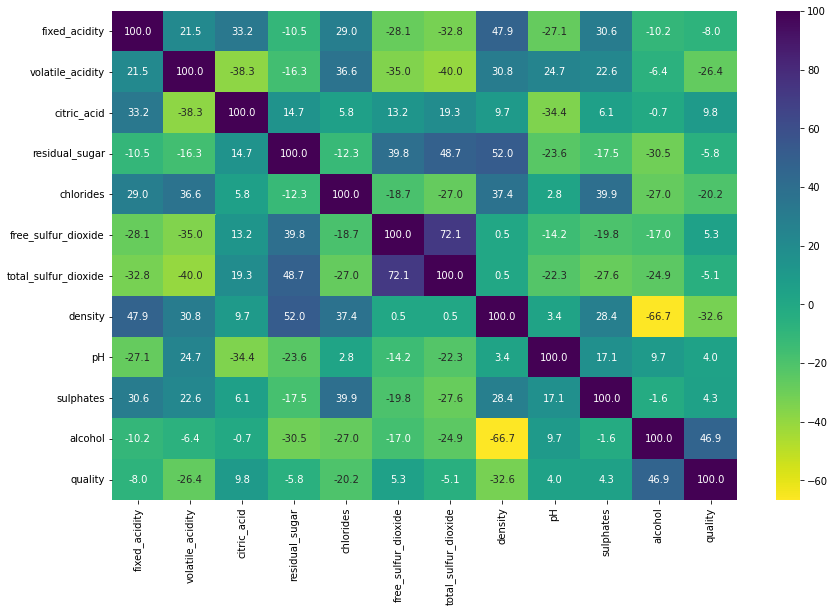

In [ ]:

'''Correlation Heat Map '''

plt.figure(figsize= (14,9))
sns.heatmap(wine.corr()*100,annot = True,fmt = ".1f",cmap ='viridis_r', )
plt.show()

- ### <font color = 'red'> Discretizing the wine quality into Low,Medium,High
 
 - #### <font color = 'blue'> Since the wine quality is listed from 3 to 9, we can create bins to group wines based on their quality into Low,Medium & High.


In [ ]:
sorted(wine.quality.unique())

wine['discrete_quality'] = wine.quality.apply(lambda x : 'Low' if x<=5 else ('High' if x>7 else 'Medium') )
wine.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,Type,quality,discrete_quality
0,7.39926,0.964904,0.000000,2.200110,0.087996,16.000800,31.99840,0.99746,3.580179,0.669933,10.20102,White,5,Low
1,12.29877,0.389961,0.630032,2.300115,0.090995,6.000300,17.99910,1.00030,3.160158,0.489951,9.50095,White,5,Low
2,6.39936,0.269973,0.490025,7.300365,0.045998,53.002650,205.98970,0.99550,3.240162,0.429957,9.20092,Red,6,Medium
3,7.39926,0.189981,0.300015,12.800640,0.052997,48.502425,228.98855,0.99850,3.140157,0.489951,9.10091,Red,7,Medium
4,6.19938,0.339966,0.300015,11.100555,0.046998,28.001400,236.98815,0.99800,3.180159,0.489951,8.70087,Red,5,Low


### Distribution of Type of wine and quality of wine

In [ ]:
wd = wine[['Type','quality']].groupby(by = ['quality']).count()
wd.reset_index(inplace = True)
wd

,quality,Type
0,3,30
1,4,204
2,5,1739
3,6,2314
4,7,855
5,8,148
6,9,5


In [ ]:
wdq = wine[['Type','discrete_quality']].groupby(by = ['discrete_quality']).count()
wdq.reset_index(inplace = True)
wdq

,discrete_quality,Type
0,High,153
1,Low,1973
2,Medium,3169


In [ ]:
wt = wine[['Type','quality']].groupby(by = ['Type']).count()
wt.reset_index(inplace = True)
wt

,Type,quality
0,Red,3943
1,White,1352


In [ ]:
wtq = wine[['Type','quality','discrete_quality','density']].groupby(by = ['Type','quality','discrete_quality']).count()
wtq.reset_index(inplace = True)
wtq

,Type,quality,discrete_quality,density
0,Red,3,Low,20
1,Red,4,Low,152
2,Red,5,Low,1168
3,Red,6,Medium,1779
4,Red,7,Medium,688
5,Red,8,High,131
6,Red,9,High,5
7,White,3,Low,10
8,White,4,Low,52
9,White,5,Low,571


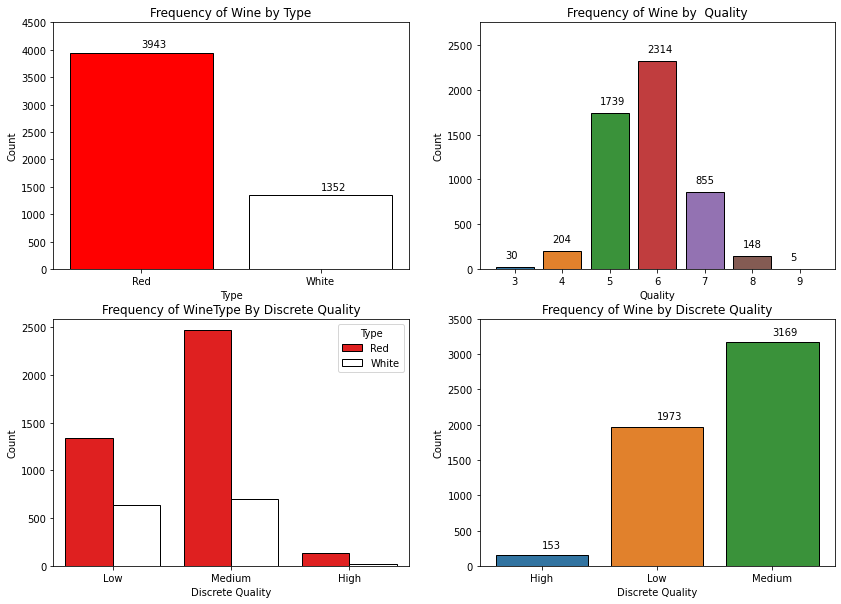

In [ ]:
plt.figure(figsize = (14,10))
plt.subplot(2,2,1)
plt.bar(x = wt.Type,height=wt.quality,color = ['Red','White'],edgecolor = 'black')
for i in range(len(wt)):
    plt.text(x =wt.Type[i] , y = wt.quality[i]+100,s = wt.quality[i])
    
plt.xlabel("Type")
plt.ylabel("Count")
plt.title("Frequency of Wine by Type")
plt.ylim([0,4500])

plt.subplot(2,2,2)
plt.bar(x = wd.quality,height=wd.Type,edgecolor = 'black',color =['#3274a1','#e1812c',
                                                                  '#3a923a','#c03d3e',
                                                                  '#9372b2','#845b53','#d684bd'] )
for i in range(len(wd)):
    plt.text(x =wd.quality[i]-0.2 , y = wd.Type[i]+100,s = wd.Type[i])
    
plt.xlabel("Quality")
plt.ylabel("Count")
plt.title("Frequency of Wine by  Quality")
plt.ylim([0,2750])


plt.subplot(2,2,3)
sns.barplot(x = wtq.discrete_quality,y = wtq.density,edgecolor = 'black',hue=wtq.Type,estimator=sum,ci = None,palette=['Red','White'])    
plt.xlabel("Discrete Quality")
plt.ylabel("Count")
plt.title("Frequency of WineType By Discrete Quality")


plt.subplot(2,2,4)
plt.bar(x = wdq.discrete_quality,height=wdq.Type,edgecolor = 'black',color =['#3274a1','#e1812c',
                                                                  '#3a923a','#c03d3e',
                                                                  '#9372b2','#845b53','#d684bd'] )
for i in range(len(wdq)):
    plt.text(x =wdq.discrete_quality[i] , y = wdq.Type[i]+100,s = wdq.Type[i])
    
plt.xlabel("Discrete Quality")
plt.ylabel("Count")
plt.title("Frequency of Wine by Discrete Quality")
plt.ylim([0,3500])
plt.show()

In [ ]:
# data
label = ["Red", "White", "Low", "Medium", "High"]
source = [0, 0, 0, 1, 1, 1]
target = [2,3,4,2,3,4]
value = [1340, 2467, 136, 633, 702, 17]

# data to dict, dict to sankey
link = dict(source = source, target = target, value = value,color = 'lightgrey')
node = dict(label = label, pad=50, thickness=15,color = ['Red','Grey','Green','Blue','orangered'])
data = go.Sankey(link = link, node=node)
# plot
fig = go.Figure(data)
fig.update_layout(font_size = 16)
fig.show()

In [ ]:
# data
label = [ "Low", "Medium", "High",'3','4','5','6','7','8','9']
source = [0, 0, 0, 1, 1, 2,2]
target = [3,4,5,6,7,8,9]
value = [30,204,1739,2314,855,148,5]

# data to dict, dict to sankey
link = dict(source = source, target = target, value = value,color = 'lightgrey')
node = dict(label = label, pad=50, thickness=10,
            color = ['Green','Blue','indianred','Green','Green','Green','Blue','Blue','indianred','indianred'])
data = go.Sankey(link = link, node=node)
# plot
fig = go.Figure(data)
fig.update_layout(font_size = 16)
fig.show()

### Detetcting Outliers

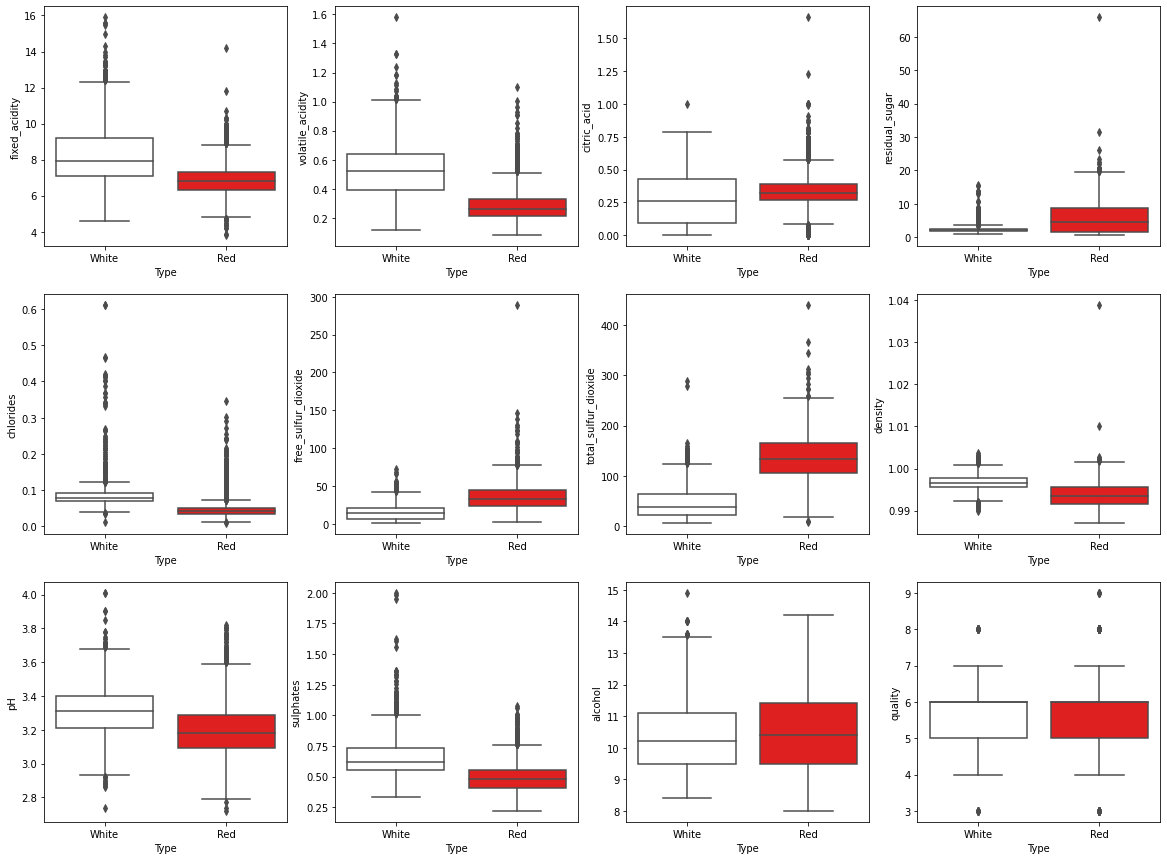

In [ ]:
''' Detetcting Outlier Visually'''

c = 0
plt.figure(figsize=(20,15))
for i in wine.select_dtypes(exclude='object').columns:
    wine = wine.dropna()
    c =c +1
    plt.subplot(3,4,c)
#     sns.boxplot(data=wine,y=i)
    sns.boxplot(data=wine,y=i,x = 'Type',palette=('#FFFFFF','red'))
    plt.ylabel(i)

- ### Analysis

    - White Type of wines contain much fixed_acidity values compared to red.
    - Residual Sugar values are very low in white wine compared to red.
    - Comparatively the Sulphur dioxide values are more in red compared to white.

- ### Outlier Analysis

    - As we can observe few of the columns like chrilides,sulphates,citric acids clearly have outliers.
    - It is suggested to remove the outliers from the data as outlier will always provide baised outputs and the analysis outcomes may be misleading.
    

- The Approch to handle outliers is to replace them with the null values.

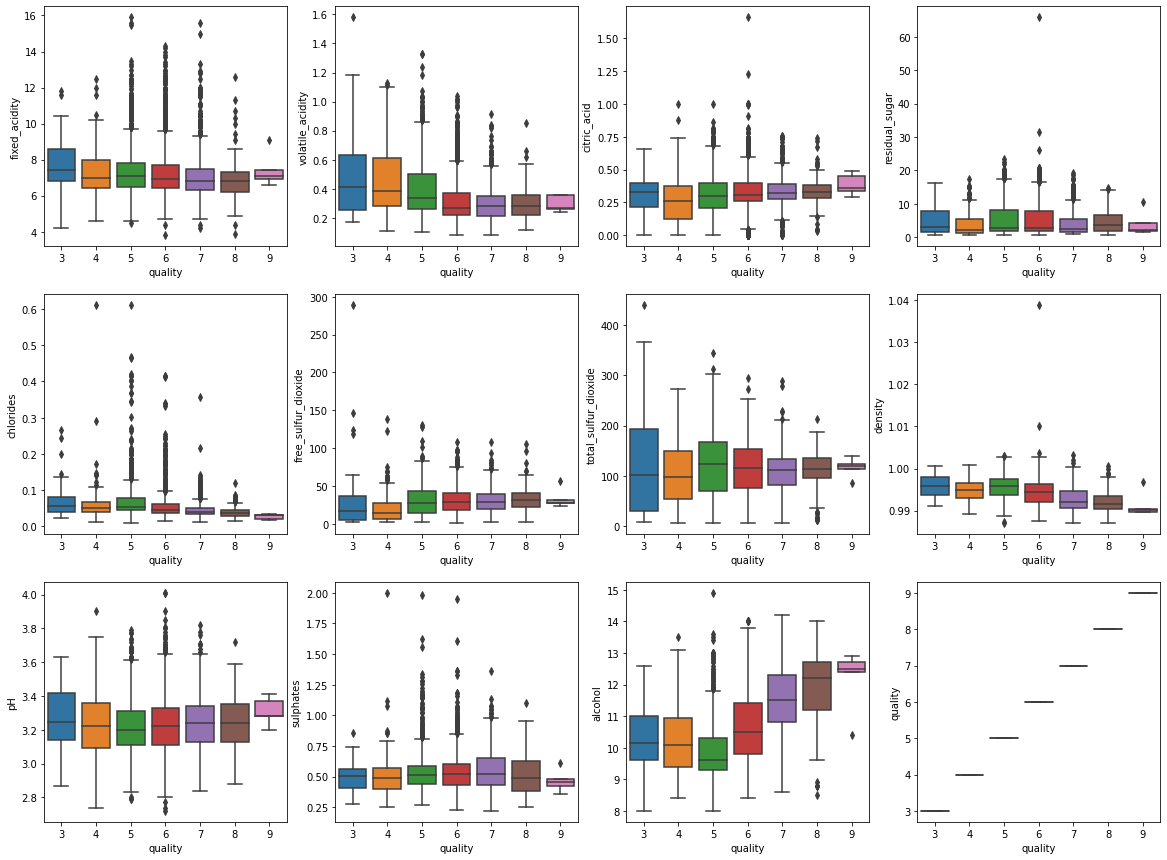

In [ ]:
c = 0
plt.figure(figsize=(20,15))
for i in wine.select_dtypes(exclude='object').columns:
    wine = wine.dropna()
    c =c +1
    plt.subplot(3,4,c)
#     sns.boxplot(data=wine,y=i)
    sns.boxplot(data=wine,y=i,x = 'quality')
    plt.ylabel(i)

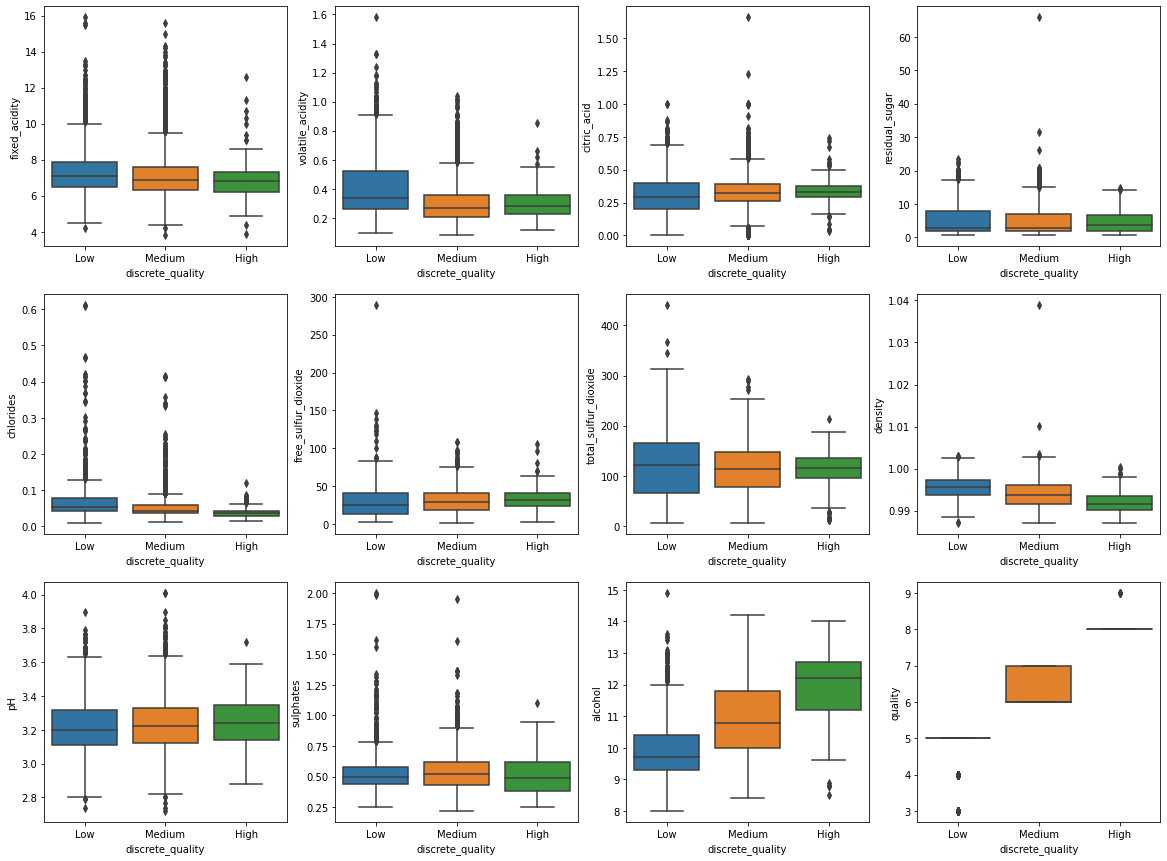

In [ ]:
c = 0
plt.figure(figsize=(20,15))
for i in wine.select_dtypes(exclude='object').columns:
    wine = wine.dropna()
    c =c +1
    plt.subplot(3,4,c)
#     sns.boxplot(data=wine,y=i)
    sns.boxplot(data=wine,y=i,x = 'discrete_quality')
    plt.ylabel(i)

- ### Analysis

    - It is intresting to see all the quality wines has almost same median values for fixed acidity , Volatile Acidity , Citric Acid, Residual Sugar , Chlorides,  Free Sulphur Dioxide , Total Sulphur Dioxide , Density , PH and sulphates.
    
    - Alchols level vary from quality to quality and as teh quality increase (i.e from low to high ) the alcohol quantity is also getting increased.

## <font color = 'blue'>Distribution of Features by Type and Quality

In [ ]:
for i in  ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol']:

    fig = ex.histogram(wine, x=i, color="Type", marginal="box",
           hover_data=wine.columns,color_discrete_sequence = ("grey",'orangered'))
    fig.update_layout(title =f"Distribution of {i} by Type of Wine",title_x = 0.5)
    fig.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
for i in  ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol']:

    fig = ex.histogram(wine, x=i, color="discrete_quality", marginal="box",
           hover_data=wine.columns)
    fig.update_layout(title = f"Distribution of {i} by Quality of Wine",title_x = 0.5)
    fig.show()

Output hidden; open in https://colab.research.google.com to view.

--- 

## <font color = 'blue'>Skewness In the Data 

- <font size = 4>The rule of thumb seems to be: 
    - If the skewness is between -0.5 and 0.5, the data are fairly symmetrical. 
    - If the skewness is between -1 and – 0.5 or between 0.5 and 1, the data are moderately skewed. 
    - If the skewness is less than -1 or greater than 1, the data are highly skewed.

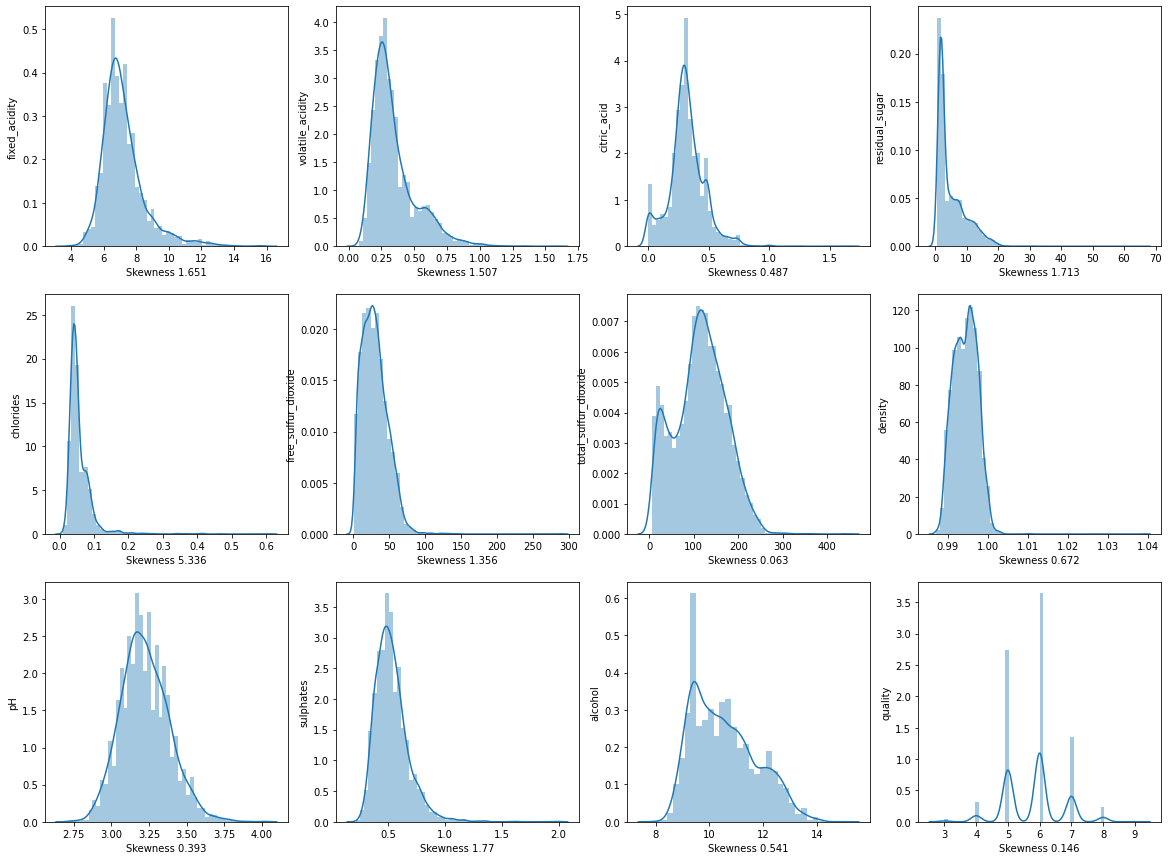

In [ ]:
c = 0
skewed_columns = []
plt.figure(figsize=(20,15))
for i in wine.select_dtypes(exclude='object').columns:
    c =c +1
    plt.subplot(3,4,c)
    sns.distplot(x = wine[i])
    if abs(wine[i].skew()) > 0.5:
        skewed_columns.append(i)
    plt.xlabel(f"Skewness {round(wine[i].skew(),3)}")
    plt.ylabel(i)

In [ ]:
fig1 = ex.histogram(wine, x='volatile_acidity', marginal="box",
       hover_data=wine.columns,color_discrete_sequence = ("grey",'orangered'))
fig1.update_layout(title =f"Before Skewness Treatment - Skewness [{round(wine['volatile_acidity'].skew(),3)}]",title_x = 0.5)

- <font size = 4>It is recommended that the data should be as symettrical as possible before building the model.So when there is a skewness greater 0.5 and less than -0.5 the data is considered either right or left skewed.

    - <font size = 4> Various transformations can be applied on the data to bring it to close to normal distribution , one of such ways to apply log transformation to the data.

['fixed_acidity', 'volatile_acidity', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'density', 'sulphates', 'alcohol']


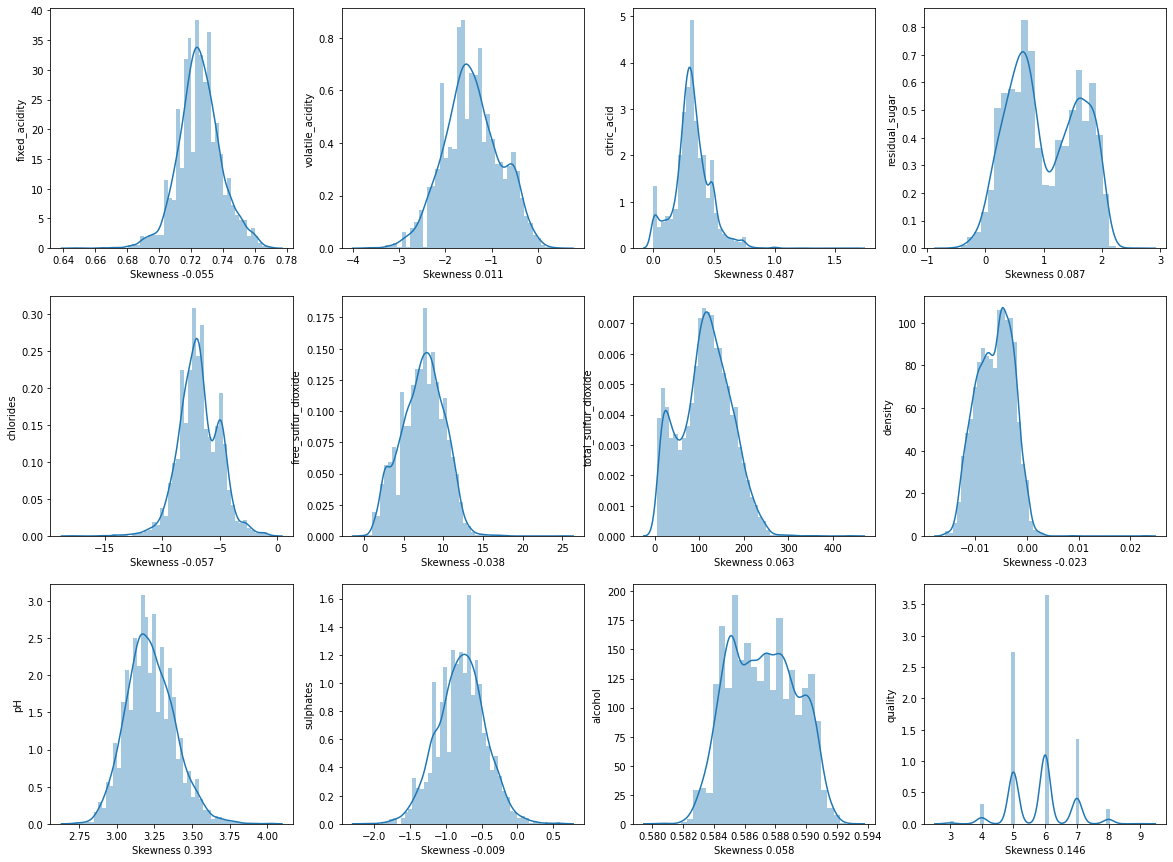

In [ ]:
print(skewed_columns)

for i in skewed_columns:
    wine[i],skewness = stats.boxcox(wine[i])    
c = 0

plt.figure(figsize=(20,15))
for i in wine.select_dtypes(exclude='object').columns:
    c =c +1
    plt.subplot(3,4,c)
    sns.distplot(x = wine[i])
    plt.xlabel(f"Skewness {round(wine[i].skew(),3)}")
    plt.ylabel(i)

In [ ]:
fig2 = ex.histogram(wine, x='volatile_acidity', marginal="box",
       hover_data=wine.columns,color_discrete_sequence = ("grey",'orangered'))
fig1.show()
fig2.update_layout(title =f"After Skewness Treatment - Skewness [{round(wine['volatile_acidity'].skew(),3)}]",title_x = 0.5)
fig2.show()

Output hidden; open in https://colab.research.google.com to view.

- ### Dealing With Outliers

In [ ]:
#Dealing with outliers 

# All outilers are replaced with null values and these values can be imputed using 

wine_outliers = wine.copy()

outlier_columns = []
for i in ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol']:
    IQR = wine_outliers[i].describe()['75%'] - wine_outliers[i].describe()['25%']
    lower = wine_outliers[i].describe()['25%'] - (1.5*IQR)
    upper = wine_outliers[i].describe()['75%'] + (1.5*IQR)
    if (((wine_outliers[i]>upper) | (wine_outliers[i]<lower)).sum() != 0):
        
        outlier_columns.append(i)
        
        '''Creating indicator columns for outliers 1 - Outlier and 0 - Not outlier'''
        wine_outliers[i+"_outlier_indicator"] = ((wine_outliers[i]>upper) | (wine_outliers[i]<lower)).apply(lambda x : 1 if x else 0)
        
        '''Replacing all outlier with NAN'''
        wine_outliers[i].loc[((wine_outliers[i]>upper) | (wine_outliers[i]<lower))] = np.nan
        
wine = wine_outliers.loc[:,wine.columns]
wine.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,Type,quality,discrete_quality
0,0.730188,-0.035906,0.000000,0.715682,-4.595977,5.398421,31.99840,-0.002640,3.580179,-0.436606,0.586807,White,5,Low
1,NaN,-1.077738,0.630032,0.751982,-4.489630,2.718778,17.99910,0.000299,3.160158,-0.833117,0.585241,White,5,Low
2,0.717377,-1.582138,0.490025,1.566687,-7.029059,10.685322,205.98970,-0.004822,3.240162,-1.014864,0.584471,Red,6,Medium
3,0.730188,-2.115251,0.300015,1.885503,-6.431593,10.191881,228.98855,-0.001535,3.140157,-0.833117,0.584200,Red,7,Medium
4,0.714249,-1.259880,0.300015,1.808788,-6.935709,7.528144,236.98815,-0.002062,3.180159,-0.833117,0.583029,Red,5,Low


- All the outliers are replaced with null values.

- These Null values can be filled with imputed values like mean or median or mode based on requirement.

# Classifying the TYPE of wine 

In [ ]:
y = wine[['Type']]
X = wine.drop(['Type','discrete_quality'],axis = 1)

In [ ]:
X.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,0.730188,-0.035906,0.000000,0.715682,-4.595977,5.398421,31.99840,-0.002640,3.580179,-0.436606,0.586807,5
1,NaN,-1.077738,0.630032,0.751982,-4.489630,2.718778,17.99910,0.000299,3.160158,-0.833117,0.585241,5
2,0.717377,-1.582138,0.490025,1.566687,-7.029059,10.685322,205.98970,-0.004822,3.240162,-1.014864,0.584471,6
3,0.730188,-2.115251,0.300015,1.885503,-6.431593,10.191881,228.98855,-0.001535,3.140157,-0.833117,0.584200,7
4,0.714249,-1.259880,0.300015,1.808788,-6.935709,7.528144,236.98815,-0.002062,3.180159,-0.833117,0.583029,5


In [ ]:
# Convert y into numeric 1 - White , 0 - Red

display(y.head())
ord_encoder =OrdinalEncoder()
y = ord_encoder.fit_transform(y)
y

,Type
0,White
1,White
2,Red
3,Red
4,Red


array([[1.],
       [1.],
       [0.],
       ...,
       [0.],
       [0.],
       [0.]])

In [ ]:
targets = list(ord_encoder.categories_[0])
targets

['Red', 'White']

#### Split Data to train and text

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,stratify=y,test_size=0.2,random_state=1)

print("Train Shape :",X_train.shape)
print("Test Shape :",X_test.shape)

Train Shape : (4236, 12)
Test Shape : (1059, 12)


## <font color = 'red'> Defining a pipeline

## Step - 1 Column Transformer

In [ ]:
# Numeric columns 
num_cols = X_train.select_dtypes(exclude = 'object').columns
cat_cols = X_train.select_dtypes(include= 'object').columns

# Numeric Preprocessing
num_imputer = KNNImputer(n_neighbors=5)


# Categorical Preprocessing
cat_imputer = SimpleImputer(strategy='most_frequent')
cat_encoder = OneHotEncoder(drop='first')

# Defining Categorical Pipeline
cat_pipeline = Pipeline(steps=[('cat_imputer',cat_imputer),
                              ('cat_encoding',cat_encoder)])

# Defininh column Transformer
column_tranformation = ColumnTransformer(transformers=[('numeric_imputer',num_imputer,num_cols),
                                        ('categorical_transformation',cat_pipeline,cat_cols)],
                                        remainder='passthrough',verbose=False)

## Step - 2 Scaling

In [ ]:
scaler = MinMaxScaler()

## Step - 3 PCA

In [ ]:
# PCA 
comp = len(num_cols)+sum([len(X_train[i].unique()) for i in cat_cols])-len(cat_cols)
pca = PCA(n_components=comp)

## Step - 4 SMOTE

In [ ]:
# SMOTE
over_samp = SMOTE(sampling_strategy='minority',random_state=1,k_neighbors=2)

## Step - 5 Model

In [ ]:
# models_dict = {"Log_clf": LogisticRegression(random_state=1),
#               "dt_clf":DecisionTreeClassifier(random_state=1),
#               "rf_clf":RandomForestClassifier(random_state=1),
#               "xgb_clf":XGBClassifier(random_state=1),
#               "knn_clf":KNeighborsClassifier(),
#               "ada_clf":AdaBoostClassifier(random_state = 1)}


m = LogisticRegression(random_state=1)

---

# PCA and WHY PCA is required ? 

Principal component analysis (PCA) is one of a family of techniques for taking high-dimensional data, and using the dependencies between the variables to represent it in a more tractable, lower-dimensional basis, without losing too much information.
It is Statistical procedure to convert observations of possibly correlated variables into 'Principal Components' that are:
- Independent of each other (Uncorrelated)
- That Captures maximum information in first few components

- **UseCases** :
    - Dimensionality reduction
    - Data visualization and Exploratory Data Analysis
    - Create uncorrelated features/variables that can be an input to a prediction model
    - Uncovering latent variables/themes/concepts
    - Noise reduction in the dataset

In [ ]:
pca_pipeline = Pipeline(steps = [("ct",column_tranformation),('sclaer',scaler),('pca',pca)])
pc_df = pd.DataFrame(pca_pipeline.fit_transform(X_train),columns = ['PC'+str(i) for i in range(1,13)],index = X_train.index)
pc_df = pc_df.iloc[:,0:3]
labels = pd.DataFrame(ord_encoder.inverse_transform(y_train),index = X_train.index,columns = ['Type'])
full_df = pd.concat([pc_df,labels],axis = 1)

In [ ]:
fig = ex.scatter_3d(full_df, x='PC1', y='PC2', z='PC3',
          color='Type',opacity=0.7,color_discrete_sequence = ('orangered','gray'))

fig.update_layout(width = 800,height = 500,title = "Visualizing the Type of wine - 3D",title_x = 0.5,title_y = 0.95)

fig.show()

In [ ]:
fig = ex.scatter(full_df, x='PC1', y='PC2',
          color='Type',opacity=0.7,color_discrete_sequence = ('orangered','gray'))

fig.update_layout(width = 800,height = 500,title = "Visualizing the Type of wine - 2D",title_x = 0.5,title_y = 0.95)

fig.show()

- ### Why Scaling is required before PCA or Model Building ?
    - Many machine learning algorithms perform better or converge faster when features are on a relatively similar scale and/or close to normally distributed.

    - Machine learning algorithm just sees number , if there is a vast difference in the range say few ranging in thousands and few ranging in the tens, and it makes the underlying assumption that higher ranging numbers have superiority of some sort.

#### PCA with out scaling

In [ ]:
pca_pipeline = Pipeline(steps = [("ct",column_tranformation),('pca',pca)])
pc_df = pd.DataFrame(pca_pipeline.fit_transform(X_train),columns = ['PC'+str(i) for i in range(1,13)],index = X_train.index)
pc_df = pc_df.iloc[:,0:3]
labels = pd.DataFrame(ord_encoder.inverse_transform(y_train),index = X_train.index,columns = ['Type'])
full_df = pd.concat([pc_df,labels],axis = 1)

In [ ]:
fig = ex.scatter(full_df, x='PC1', y='PC2',
          color='Type',opacity=0.7,color_discrete_sequence = ('orangered','gray'))

fig.update_layout(width = 800,height = 500,title = "Visualizing the Type of wine - 2D",title_x = 0.5,title_y = 0.95)

fig.show()

### How to Handle Imbalanced classes ? 

- Most machine learning algorithms work best when the number of samples in each class are about equal. This is because most algorithms are designed to maximize accuracy and reduce errors.
- However, if the data set in imbalance then In such cases, you get a **pretty high accuracy just by predicting the majority class, but you fail to capture the minority class**, which is most often the point of creating the model in the first place.

### Oversampling Minority Classes

- **SMOTE** is an oversampling technique where the synthetic samples are generated for the minority class. This algorithm helps to overcome the overfitting problem posed by random oversampling. It focuses on the feature space to generate new instances with the help of interpolation between the positive instances that lie together.

In [ ]:
pca_pipeline = make_pipeline(column_tranformation,scaler,pca,over_samp)
ox,oy = pca_pipeline.fit_resample(X_train,y_train)
pc_df = pd.DataFrame(ox,columns = ['PC'+str(i) for i in range(1,13)])
pc_df = pc_df.iloc[:,0:3]
labels = pd.DataFrame(ord_encoder.inverse_transform(oy.reshape(-1,1)),columns = ['Type'])
full_df = pd.concat([pc_df,labels],axis = 1)

In [ ]:
fig = ex.scatter(full_df, x='PC1', y='PC2',
          color='Type',opacity=0.7,color_discrete_sequence = ('orangered','gray'))

fig.update_layout(width = 800,height = 500,title = "Visualizing the Type of wine - Oversampled - 2D",title_x = 0.5,title_y = 0.95)

fig.show()

# Metrics

In [ ]:
def model_metrics(grid,model_type,X_test = X_test,y_test = y_test,targets = targets):
    
    print("\n")
    print("Best Accuracy:")
    print('-'*50)
    results = pd.DataFrame(grid.cv_results_)
    sel_cols = [i for i in results if i.find('param') != -1]
    sel_cols.extend(['mean_train_score','mean_test_score'])
    results = results.loc[:,sel_cols]
    display(results[results.params == grid.best_params_])
    print("\n")
    
    
    print("\n")
    print("Best Parameters:")
    print('-'*50)
    print(grid.best_params_)
    print("\n")
    
        
    y_pred = grid.best_estimator_.predict(X_test)
    y_pred_prob = grid.best_estimator_.predict_proba(X_test)

    features = X_test.columns

    print("Performance Metrics:")
    print("-"*50)
    print("Accuracy",round(accuracy_score(y_test,y_pred),2))
    print("Precision",round(precision_score(y_test,y_pred),2))
    print("Recall",round(recall_score(y_test,y_pred),2))

    print("\n","Confusion Matrix :")
    print("-"*50)
    cm = confusion_matrix(y_test,y_pred)
    total_classes = len(targets)
    codes = [total_classes*[0], list(range(total_classes))]
    cm = confusion_matrix(y_test, y_pred)
    
    display(cm)
    sns.heatmap(cm,annot=True,fmt="d",cbar = False)
    plt.xticks([0.5,1.5],labels=targets)
    plt.yticks([0.5,1.5],labels=targets)
    plt.title('Confusion matrix')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.show()

    print("\n","Classification Report :")
    print("-"*50)
    print(classification_report(y_test,y_pred,target_names=targets))

    fpr, tpr, thresh = roc_curve(y_test, y_pred_prob[:,1],pos_label=1)

    # plotting 
    plt.plot(fpr, tpr,color='red')
    plt.plot([(0,0),(1,1)],linestyle = "--",color = "black")
    plt.legend((f"ROC - {round(roc_auc_score(y_test,y_pred),4)}","Random"))
    plt.title('ROC curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel("True Positive Rate")
    plt.show()

    pre,rec,thresh = precision_recall_curve(y_test, y_pred_prob[:,1],pos_label=1) 
    plt.plot(rec, pre,color='red')
    plt.plot([(0,0),(1,1)],linestyle = "--",color = "black")
    plt.legend((f"White vs Red","Random"))
    plt.title('Precision - Recall curve')
    plt.xlabel('Recall')
    plt.ylabel("Precision")
    plt.show()
    

#     try:        
#         # Variable importance
#         importance = pd.DataFrame({'features': features,'importance': grid.best_estimator_.named_steps[model_type].feature_importances_})
#         importance.index=importance.features
#         importance.sort_values(by='importance', ascending=True).plot.barh()
#         plt.legend(loc='lower right')
#         plt.title("Feature Importance Plot")
#         plt.show()
#     except:
#         importance = pd.DataFrame(grid.best_estimator_.named_steps[model_type].coef_).T
#         importance.columns = ['importance']
#         importance.index = features
#         importance.sort_values(by='importance', ascending=True).plot.barh()
#         plt.legend(loc='lower right')
#         plt.title("Feature Importance Plot")
#         plt.show() 

In [ ]:
def model_metrics_pl(grid,model_type,X_test = X_test,y_test = y_test,targets = targets):
    
    print("\n")
    print("Best Accuracy:")
    print('-'*50)
    results = pd.DataFrame(grid.cv_results_)
    sel_cols = [i for i in results if i.find('param') != -1]
    sel_cols.extend(['mean_train_score','mean_test_score'])
    results = results.loc[:,sel_cols]
    display(results[results.params == grid.best_params_])
    print("\n")
    
    
    print("\n")
    print("Best Parameters:")
    print('-'*50)
    print(grid.best_params_)
    print("\n")
    
        
    y_pred = grid.best_estimator_.predict(X_test)
    y_pred_prob = grid.best_estimator_.predict_proba(X_test)

    features = X_test.columns

    print("Performance Metrics:")
    print("-"*50)
    print("Accuracy",round(accuracy_score(y_test,y_pred),2))
    print("Precision",round(precision_score(y_test,y_pred),2))
    print("Recall",round(recall_score(y_test,y_pred),2))

    cm = confusion_matrix(y_test,y_pred)
    total_classes = len(targets)
    codes = [total_classes*[0], list(range(total_classes))]
    cm = confusion_matrix(y_test, y_pred)
    
    print("\n","Classification Report :")
    print("-"*50)
    print(classification_report(y_test,y_pred,target_names=targets))

    fig = make_subplots(rows = 2,cols=2,horizontal_spacing=0.15,vertical_spacing=0.12,
                        subplot_titles=("Confusion Matrix","Feature Importance","ROC - Curve",
                                                                               "Precision - Recall Curve"))


    fig.add_trace(go.Heatmap(z= cm[::-1],x=targets,y=targets[::-1],colorscale='oranges',showscale = False),row=1,col=1)
    fig.update_xaxes(title_text="Predicted",row=1, col=1)
    fig.update_yaxes(title_text="Actual",row=1, col=1)


    fig.add_annotation(dict(x=0.0350, y=0.925, xref="paper", yref="paper", 
                                text=f"True Negative {cm[0,0]}",font=dict(
            family="sans serif",
            size=15,
            color="black"
        ),showarrow=False))
    fig.add_annotation(dict(x=0.3350, y=0.925, xref="paper",font=dict(
            family="sans serif",
            size=15,
            color="black"
        ), yref="paper", 
                                text=f"False Positive {cm[0,1]}",showarrow=False))
    fig.add_annotation(dict(x=0.0350, y=0.725, xref="paper",font=dict(
            family="sans serif",
            size=15,
            color="black"
        ), yref="paper", 
                                text=f"False Negative {cm[1,0]}",showarrow=False))
    fig.add_annotation(dict(x=0.3350, y=0.725, xref="paper", yref="paper", 
                                text=f"True Postive {cm[1,1]}",font=dict(
            family="sans serif",
            size=15,
            color="black"
        ),showarrow=False))



    fpr, tpr, thresh = roc_curve(y_test, y_pred_prob[:,1],pos_label=1)
    fig.add_trace(go.Scatter(x=fpr,y=tpr,hovertext = np.round(thresh,3),line ={'color' : 'orangered'}),row=2,col=1)
    fig.add_trace(go.Scatter(x=[0,1],y=[0,1],line ={'dash':'dash','color' : 'black'}),row=2,col=1)
    fig.update_xaxes(title_text="False Positive Rate",row=2, col=1)
    fig.update_yaxes(title_text="True Positive Rate",row=2, col=1)
    fig.update_traces(showlegend = False)
    fig.add_annotation(dict(x=0.175, y=0.05, xref="paper", yref="paper", 
                        text=f"ROC - {round(roc_auc_score(y_test,y_pred),4)}",font=dict(
    family="sans serif",
    size=15,
    color="black"
),showarrow=False))


    pre,rec,thresh = precision_recall_curve(y_test, y_pred_prob[:,1],pos_label=1) 
    fig.add_trace(go.Scatter(x=rec,y=pre,hovertext = np.round(thresh,3),line ={'color' : 'orangered'}),row=2,col=2)
    fig.add_trace(go.Scatter(x=[0,1],y=[0,1],line ={'dash':'dash','color' : 'black'}),row=2,col=2)
    fig.update_xaxes(title_text="Recall",row=2, col=2)
    fig.update_yaxes(title_text="Precision",row=2, col=2)
    fig.update_traces(showlegend = False)
    fig.add_annotation(dict(x=0.850, y=0.05, xref="paper", yref="paper", 
                        text=f"White vs Red",font=dict(
    family="sans serif",
    size=15,
    color="black"
),showarrow=False))

    try:        
        # Variable importance
        importance = pd.DataFrame({'features': features,'importance': grid.best_estimator_.named_steps[model_type].feature_importances_})
        importance.index=importance.features
        importance = importance.sort_values(by='importance', ascending=True)
        color = np.where(importance.importance>0,'lightgreen','orangered')
        fig.add_trace(go.Bar(x=list(importance.importance),y=list(importance.index),orientation='h',
                            marker=dict(color=color)),row=1,col=2)
        fig.update_traces(showlegend = False) 
        fig.update_layout(height = 700,width = 1000,paper_bgcolor = 'rgba(0,0,0,0)')
        fig.show()

    except:
        importance = pd.DataFrame(grid.best_estimator_.named_steps[model_type].coef_).T
        importance.columns = ['importance']
        importance.index = features
        importance = importance.sort_values(by='importance', ascending=True)
        color = np.where(importance.importance>0,'lightgreen','orangered')
        fig.add_trace(go.Bar(x=list(importance.importance),y=list(importance.index),orientation='h',
                            marker=dict(color=color)),row=1,col=2)
        fig.update_traces(showlegend = False) 
        fig.update_layout(height = 700,width = 1000,paper_bgcolor = 'rgba(0,0,0,0)')
        fig.show()

## Model - 1  Logistic Regression 

Fitting 5 folds for each of 2 candidates, totalling 10 fits


Pipeline(steps=[('columntranformation',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric_imputer',
                                                  KNNImputer(),
                                                  Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')),
                                                 ('categorical_transformation',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cat_encoding',
                                                                   OneHotEncoder(drop='first'))]),
                                                  Index([], dtype='object'))])),
                ('scaler', MinMaxScaler()),
                ('pca', PCA(n_components=12, whiten=True)),
                ('logisticregression',
                 LogisticRegression(random_state=1, tol=0.01))])



Best Accuracy:
--------------------------------------------------


,param_logisticregression__C,param_logisticregression__class_weight,param_logisticregression__penalty,param_logisticregression__solver,param_logisticregression__tol,param_pca__n_components,param_pca__whiten,params,mean_train_score,mean_test_score
0,1,None,l2,lbfgs,0.01,12,True,"{'logisticregression__C': 1.0, 'logisticregres...",0.994275,0.993391






Best Parameters:
--------------------------------------------------
{'logisticregression__C': 1.0, 'logisticregression__class_weight': None, 'logisticregression__penalty': 'l2', 'logisticregression__solver': 'lbfgs', 'logisticregression__tol': 0.01, 'pca__n_components': 12, 'pca__whiten': True}


Performance Metrics:
--------------------------------------------------
Accuracy 0.99
Precision 1.0
Recall 0.98

 Confusion Matrix :
--------------------------------------------------


array([[788,   1],
       [  5, 265]])

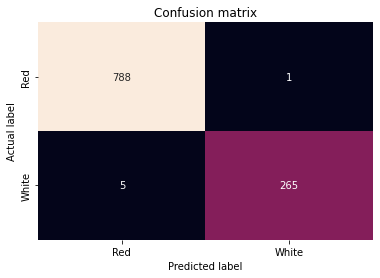


 Classification Report :
--------------------------------------------------
              precision    recall  f1-score   support

         Red       0.99      1.00      1.00       789
       White       1.00      0.98      0.99       270

    accuracy                           0.99      1059
   macro avg       0.99      0.99      0.99      1059
weighted avg       0.99      0.99      0.99      1059



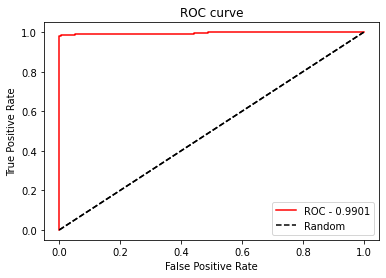

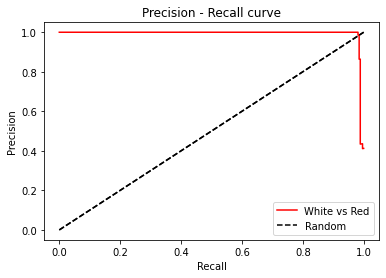

In [ ]:
pipeline = Pipeline(steps=[('columntranformation',column_tranformation),
                          ('scaler',scaler),
                          ('pca',pca),
                          ('logisticregression',m)])

imb_pipeline = make_pipeline(column_tranformation,scaler,pca,over_samp,m)

param = {'pca__whiten':[True],
         'pca__n_components':[12]
         ,'logisticregression__C': [1.0]
                          ,'logisticregression__solver': ['lbfgs'] 
                          ,'logisticregression__penalty': [ 'l2']
                          ,'logisticregression__tol' : [0.01] 
                          ,'logisticregression__class_weight': [None,'balanced']}

grid = GridSearchCV(estimator=pipeline,
                cv=5,
                param_grid = param,
                verbose=1,
                return_train_score=True,
                n_jobs=-1,
               scoring='accuracy')

grid.fit(X_train,y_train)

set_config(display='diagram')
display(grid.best_estimator_)  


model_metrics(grid,'logisticregression')

Fitting 5 folds for each of 4 candidates, totalling 20 fits


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric_imputer',
                                                  KNNImputer(),
                                                  Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')),
                                                 ('categorical_transformation',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cat_encoding',
                                                                   OneHotEncoder(drop='first'))]),
                                                  Index([], dtype='object'))])),
                ('minmaxscaler', MinMaxScaler()),
                ('pca', PCA(n_components=12, whiten=True)),
                ('smote',
                 SMOTE(k_neighbors=7, random_state=1,
                       sampling_strategy='minority')),
                ('logisticregression',
                 LogisticRegression(random_state=1, tol=0.01))])



Best Accuracy:
--------------------------------------------------


,param_logisticregression__C,param_logisticregression__class_weight,param_logisticregression__penalty,param_logisticregression__solver,param_logisticregression__tol,param_pca__n_components,param_pca__whiten,param_smote__k_neighbors,params,mean_train_score,mean_test_score
0,1,None,l2,lbfgs,0.01,12,True,7,"{'logisticregression__C': 1.0, 'logisticregres...",0.993744,0.993627






Best Parameters:
--------------------------------------------------
{'logisticregression__C': 1.0, 'logisticregression__class_weight': None, 'logisticregression__penalty': 'l2', 'logisticregression__solver': 'lbfgs', 'logisticregression__tol': 0.01, 'pca__n_components': 12, 'pca__whiten': True, 'smote__k_neighbors': 7}


Performance Metrics:
--------------------------------------------------
Accuracy 0.99
Precision 0.99
Recall 0.98

 Confusion Matrix :
--------------------------------------------------


array([[787,   2],
       [  5, 265]])

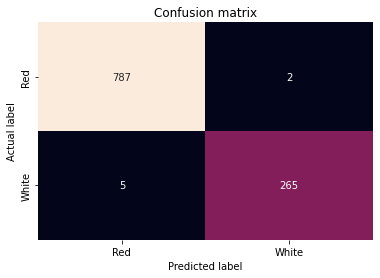


 Classification Report :
--------------------------------------------------
              precision    recall  f1-score   support

         Red       0.99      1.00      1.00       789
       White       0.99      0.98      0.99       270

    accuracy                           0.99      1059
   macro avg       0.99      0.99      0.99      1059
weighted avg       0.99      0.99      0.99      1059



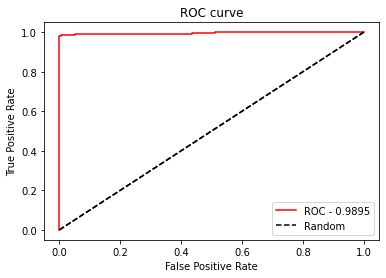

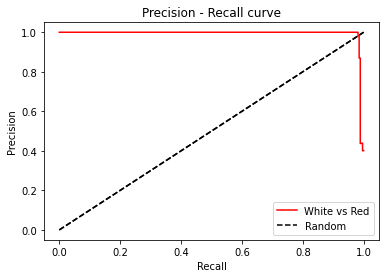

In [ ]:
pipeline = Pipeline(steps=[('columntranformation',column_tranformation),
                          ('scaler',scaler),
                          ('pca',pca),
                          ('logisticregression',m)])

imb_pipeline = make_pipeline(column_tranformation,scaler,pca,over_samp,m)

param = {'smote__k_neighbors':[7]
         ,'pca__whiten':[True],
         'pca__n_components':[12]
    ,'logisticregression__C': [1.0]
                          ,'logisticregression__solver': ['lbfgs', 'liblinear'] 
                          ,'logisticregression__penalty': [ 'l2']
                          ,'logisticregression__tol' : [0.01] 
                          ,'logisticregression__class_weight': [None,'balanced']}

grid = GridSearchCV(estimator=imb_pipeline,
                cv=5,
                param_grid = param,
                verbose=1,
                return_train_score=True,
                n_jobs=-1,
               scoring='accuracy')

grid.fit(X_train,y_train)

set_config(display='diagram')
display(grid.best_estimator_)  


model_metrics(grid,'logisticregression')


## Model - 2  Decision Tree Classifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits


Pipeline(steps=[('columntranformation',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric_imputer',
                                                  KNNImputer(),
                                                  Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')),
                                                 ('categorical_transformation',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cat_encoding',
                                                                   OneHotEncoder(drop='first'))]),
                                                  Index([], dtype='object'))])),
                ('scaler', MinMaxScaler()),
                ('pca', PCA(n_components=11, whiten=True)),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(max_depth=4, max_features=10,
                                        min_samples_split=3, random_state=1))])



Best Accuracy:
--------------------------------------------------


,param_decisiontreeclassifier__max_depth,param_decisiontreeclassifier__max_features,param_decisiontreeclassifier__min_samples_split,param_pca__n_components,param_pca__whiten,params,mean_train_score,mean_test_score
0,4,10,3,11,True,"{'decisiontreeclassifier__max_depth': 4, 'deci...",0.989731,0.981825






Best Parameters:
--------------------------------------------------
{'decisiontreeclassifier__max_depth': 4, 'decisiontreeclassifier__max_features': 10, 'decisiontreeclassifier__min_samples_split': 3, 'pca__n_components': 11, 'pca__whiten': True}


Performance Metrics:
--------------------------------------------------
Accuracy 0.98
Precision 0.97
Recall 0.97

 Confusion Matrix :
--------------------------------------------------


array([[780,   9],
       [  9, 261]])

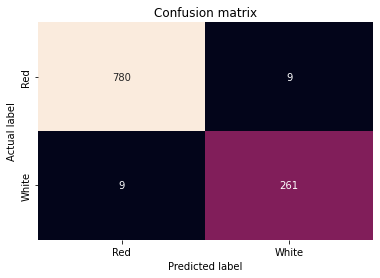


 Classification Report :
--------------------------------------------------
              precision    recall  f1-score   support

         Red       0.99      0.99      0.99       789
       White       0.97      0.97      0.97       270

    accuracy                           0.98      1059
   macro avg       0.98      0.98      0.98      1059
weighted avg       0.98      0.98      0.98      1059



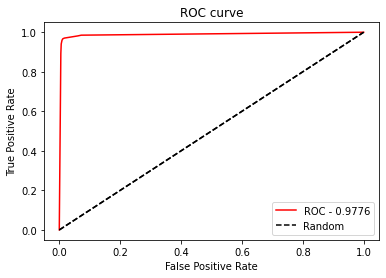

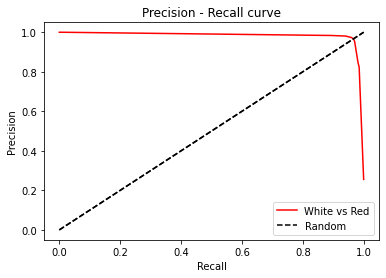

In [ ]:
pipeline = Pipeline(steps=[('columntranformation',column_tranformation),
                          ('scaler',scaler),
                          ('pca',pca),
                          ('decisiontreeclassifier',DecisionTreeClassifier(random_state=1))])

imb_pipeline = make_pipeline(column_tranformation,scaler,pca,over_samp,DecisionTreeClassifier(random_state=1))

# param = {'pca__whiten':[True,False],
#          'pca__n_components':[7,8,9,10,11,12]
#     ,'decisiontreeclassifier__max_depth':[4,5,6,8,10,12]
#                        ,'decisiontreeclassifier__min_samples_split':[2,3,4],
#                        'decisiontreeclassifier__max_features':[8,9,10,11,12],
# # #                         'decisiontreeclassifier__max_leaf_nodes':[10,20,40,None]

param = {'pca__whiten':[True],
         'pca__n_components':[11]
    ,'decisiontreeclassifier__max_depth':[4]
                       ,'decisiontreeclassifier__min_samples_split':[3],
                       'decisiontreeclassifier__max_features':[10],
# #                         'decisiontreeclassifier__max_leaf_nodes':[10,20,40,None]
        }

grid = GridSearchCV(estimator=pipeline,
                cv=5,
                param_grid = param,
                verbose=2,
                return_train_score=True,
                n_jobs=-1,
               scoring='accuracy')

grid.fit(X_train,y_train)

set_config(display='diagram')
display(grid.best_estimator_)   

model_metrics(grid,'decisiontreeclassifier')

Fitting 5 folds for each of 1 candidates, totalling 5 fits


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric_imputer',
                                                  KNNImputer(),
                                                  Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')),
                                                 ('categorical_transformation',...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cat_encoding',
                                                                   OneHotEncoder(drop='first'))]),
                                                  Index([], dtype='object'))])),
                ('minmaxscaler', MinMaxScaler()), ('pca', PCA(n_components=11)),
                ('smote',
                 SMOTE(k_neighbors=6, random_state=1,
                       sampling_strategy='minority')),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(max_depth=4, max_features=10,
                                        min_samples_split=4, random_state=1))])



Best Accuracy:
--------------------------------------------------


,param_decisiontreeclassifier__max_depth,param_decisiontreeclassifier__max_features,param_decisiontreeclassifier__min_samples_split,param_pca__n_components,param_pca__whiten,param_smote__k_neighbors,params,mean_train_score,mean_test_score
0,4,10,4,11,False,6,"{'decisiontreeclassifier__max_depth': 4, 'deci...",0.987488,0.981116






Best Parameters:
--------------------------------------------------
{'decisiontreeclassifier__max_depth': 4, 'decisiontreeclassifier__max_features': 10, 'decisiontreeclassifier__min_samples_split': 4, 'pca__n_components': 11, 'pca__whiten': False, 'smote__k_neighbors': 6}


Performance Metrics:
--------------------------------------------------
Accuracy 0.98
Precision 0.96
Recall 0.96

 Confusion Matrix :
--------------------------------------------------


array([[779,  10],
       [ 10, 260]])

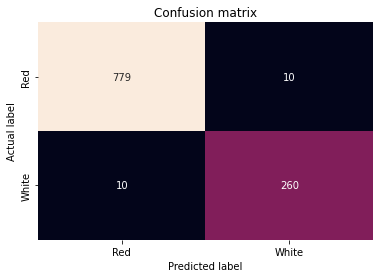


 Classification Report :
--------------------------------------------------
              precision    recall  f1-score   support

         Red       0.99      0.99      0.99       789
       White       0.96      0.96      0.96       270

    accuracy                           0.98      1059
   macro avg       0.98      0.98      0.98      1059
weighted avg       0.98      0.98      0.98      1059



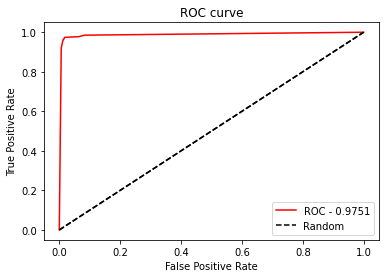

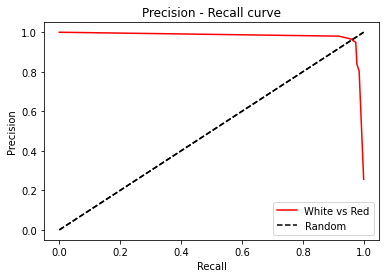

In [ ]:
pipeline = Pipeline(steps=[('columntranformation',column_tranformation),
                          ('scaler',scaler),
                          ('pca',pca),
                          ('decisiontreeclassifier',DecisionTreeClassifier(random_state=1))])

imb_pipeline = make_pipeline(column_tranformation,scaler,pca,over_samp,DecisionTreeClassifier(random_state=1))

param = {'smote__k_neighbors':[6]
         ,'pca__whiten':[False],
         'pca__n_components':[11]
    ,'decisiontreeclassifier__max_depth':[4]
                       ,'decisiontreeclassifier__min_samples_split':[4],
                       'decisiontreeclassifier__max_features':[10],
        }

grid = GridSearchCV(estimator=imb_pipeline,
                cv=5,
                param_grid = param,
                verbose=2,
                return_train_score=True,
                n_jobs=-1,
               scoring='accuracy')

grid.fit(X_train,y_train)

set_config(display='diagram')
display(grid.best_estimator_)   

model_metrics(grid,'decisiontreeclassifier')


## Model - 3  Random Forest Classifier 

Fitting 5 folds for each of 2 candidates, totalling 10 fits


Pipeline(steps=[('columntranformation',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric_imputer',
                                                  KNNImputer(),
                                                  Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')),
                                                 ('categorical_transformation',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cat_encoding',
                                                                   OneHotEncoder(drop='first'))]),
                                                  Index([], dtype='object'))])),
                ('scaler', MinMaxScaler()),
                ('pca', PCA(n_components=12, whiten=True)),
                ('randomforestclassifier',
                 RandomForestClassifier(max_depth=8, max_features=5,
                                        n_estimators=200, random_state=1))])



Best Accuracy:
--------------------------------------------------


,param_pca__whiten,param_randomforestclassifier__max_depth,param_randomforestclassifier__max_features,param_randomforestclassifier__min_samples_split,param_randomforestclassifier__n_estimators,params,mean_train_score,mean_test_score
0,True,8,5,2,200,"{'pca__whiten': True, 'randomforestclassifier_...",0.998111,0.988906






Best Parameters:
--------------------------------------------------
{'pca__whiten': True, 'randomforestclassifier__max_depth': 8, 'randomforestclassifier__max_features': 5, 'randomforestclassifier__min_samples_split': 2, 'randomforestclassifier__n_estimators': 200}


Performance Metrics:
--------------------------------------------------
Accuracy 0.99
Precision 0.99
Recall 0.97

 Confusion Matrix :
--------------------------------------------------


array([[786,   3],
       [  9, 261]])

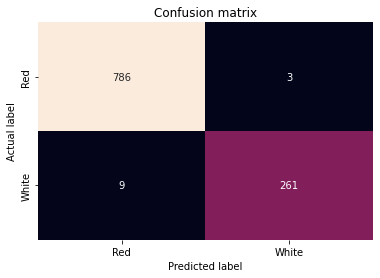


 Classification Report :
--------------------------------------------------
              precision    recall  f1-score   support

         Red       0.99      1.00      0.99       789
       White       0.99      0.97      0.98       270

    accuracy                           0.99      1059
   macro avg       0.99      0.98      0.98      1059
weighted avg       0.99      0.99      0.99      1059



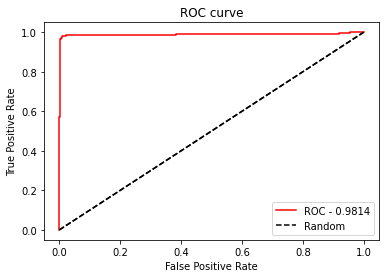

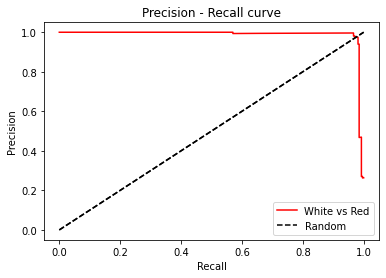

In [ ]:
pipeline = Pipeline(steps=[('columntranformation',column_tranformation),
                          ('scaler',scaler),
                          ('pca',pca),
                          ('randomforestclassifier',RandomForestClassifier(random_state=1))])

imb_pipeline = make_pipeline(column_tranformation,scaler,pca,over_samp,RandomForestClassifier(random_state=1))

param = {'pca__whiten':[True,False]
    ,'randomforestclassifier__n_estimators':[200],
                        'randomforestclassifier__max_depth':[8],
                       'randomforestclassifier__min_samples_split':[2],
                       'randomforestclassifier__max_features':[5],
#                         'randomforestclassifier__ccp_alpha':[0.001]
        }

grid = GridSearchCV(estimator=pipeline,
                cv=5,
                param_grid = param,
                verbose=2,
                return_train_score=True,
                n_jobs=-1,
               scoring='accuracy')

grid.fit(X_train,y_train)

set_config(display='diagram')
display(grid.best_estimator_)   

model_metrics(grid,'randomforestclassifier')

Fitting 5 folds for each of 1 candidates, totalling 5 fits


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric_imputer',
                                                  KNNImputer(),
                                                  Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')),
                                                 ('categorical_transformation',...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cat_encoding',
                                                                   OneHotEncoder(drop='first'))]),
                                                  Index([], dtype='object'))])),
                ('minmaxscaler', MinMaxScaler()), ('pca', PCA(n_components=12)),
                ('smote',
                 SMOTE(k_neighbors=7, random_state=1,
                       sampling_strategy='minority')),
                ('randomforestclassifier',
                 RandomForestClassifier(max_depth=10, max_features=6,
                                        n_estimators=200, random_state=1))])



Best Accuracy:
--------------------------------------------------


,param_pca__whiten,param_randomforestclassifier__max_depth,param_randomforestclassifier__max_features,param_randomforestclassifier__min_samples_split,param_randomforestclassifier__n_estimators,param_smote__k_neighbors,params,mean_train_score,mean_test_score
0,False,10,6,2,200,7,"{'pca__whiten': False, 'randomforestclassifier...",0.99941,0.988434






Best Parameters:
--------------------------------------------------
{'pca__whiten': False, 'randomforestclassifier__max_depth': 10, 'randomforestclassifier__max_features': 6, 'randomforestclassifier__min_samples_split': 2, 'randomforestclassifier__n_estimators': 200, 'smote__k_neighbors': 7}


Performance Metrics:
--------------------------------------------------
Accuracy 0.99
Precision 0.99
Recall 0.98

 Confusion Matrix :
--------------------------------------------------


array([[785,   4],
       [  6, 264]])

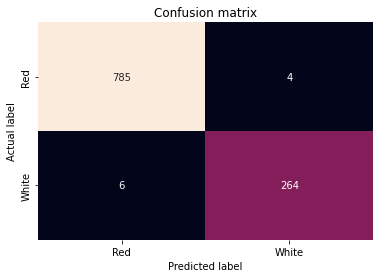


 Classification Report :
--------------------------------------------------
              precision    recall  f1-score   support

         Red       0.99      0.99      0.99       789
       White       0.99      0.98      0.98       270

    accuracy                           0.99      1059
   macro avg       0.99      0.99      0.99      1059
weighted avg       0.99      0.99      0.99      1059



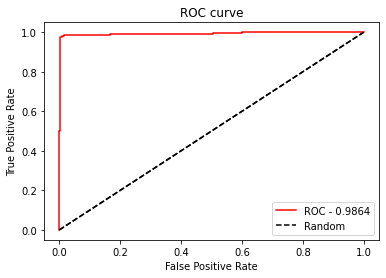

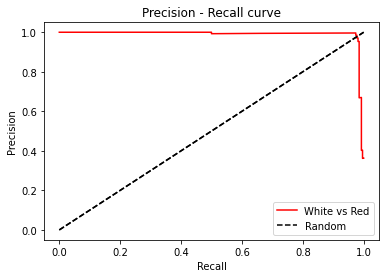

In [ ]:
pipeline = Pipeline(steps=[('columntranformation',column_tranformation),
                          ('scaler',scaler),
                          ('pca',pca),
                          ('randomforestclassifier',RandomForestClassifier(random_state=1))])

imb_pipeline = make_pipeline(column_tranformation,scaler,pca,over_samp,RandomForestClassifier(random_state=1))

param = {'pca__whiten':[False],
         'smote__k_neighbors':[7]
    ,'randomforestclassifier__n_estimators':[200],
                        'randomforestclassifier__max_depth':[10],
                       'randomforestclassifier__min_samples_split':[2],
                       'randomforestclassifier__max_features':[6],
#                         'randomforestclassifier__ccp_alpha':[0.001]
        }

grid = GridSearchCV(estimator=imb_pipeline,
                cv=5,
                param_grid = param,
                verbose=2,
                return_train_score=True,
                n_jobs=-1,
               scoring='accuracy')

grid.fit(X_train,y_train)

set_config(display='diagram')
display(grid.best_estimator_)   

model_metrics(grid,'randomforestclassifier')

## Model - 4  XGBoost Classifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits


Pipeline(steps=[('columntranformation',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric_imputer',
                                                  KNNImputer(),
                                                  Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')),
                                                 ('categorical_transformation',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cat_encoding',
                                                                   OneHotEncoder(drop='first'))]),
                                                  Index([], dtype='object'))])),
                ('scaler', MinMaxScaler()),
                ('pca', PCA(n_components=12, whiten=True)),
                ('xgbclassifier',
                 XGBClassifier(eval_metric='mlogloss', max_depth=4,
                               n_estimators=500, random_state=1, reg_lambda=50,
                               subsample=0.9))])



Best Accuracy:
--------------------------------------------------


,param_pca__whiten,param_xgbclassifier__learning_rate,param_xgbclassifier__max_depth,param_xgbclassifier__n_estimators,param_xgbclassifier__reg_lambda,param_xgbclassifier__subsample,params,mean_train_score,mean_test_score
0,True,0.1,4,500,50,0.9,"{'pca__whiten': True, 'xgbclassifier__learning...",0.998466,0.993628






Best Parameters:
--------------------------------------------------
{'pca__whiten': True, 'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__max_depth': 4, 'xgbclassifier__n_estimators': 500, 'xgbclassifier__reg_lambda': 50, 'xgbclassifier__subsample': 0.9}


Performance Metrics:
--------------------------------------------------
Accuracy 0.99
Precision 0.99
Recall 0.98

 Confusion Matrix :
--------------------------------------------------


array([[786,   3],
       [  5, 265]])

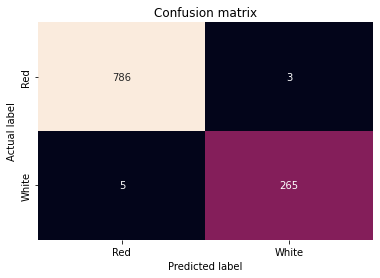


 Classification Report :
--------------------------------------------------
              precision    recall  f1-score   support

         Red       0.99      1.00      0.99       789
       White       0.99      0.98      0.99       270

    accuracy                           0.99      1059
   macro avg       0.99      0.99      0.99      1059
weighted avg       0.99      0.99      0.99      1059



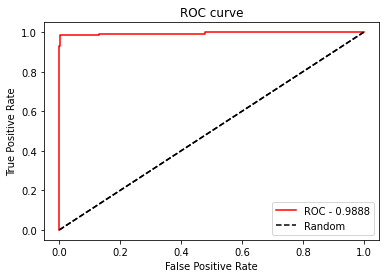

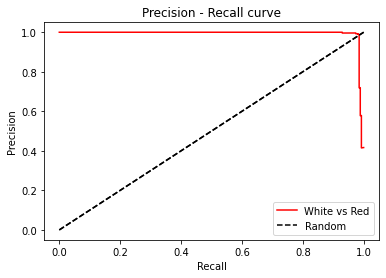

In [ ]:
pipeline = Pipeline(steps=[('columntranformation',column_tranformation),
                          ('scaler',scaler),
                          ('pca',pca),
                          ('xgbclassifier',XGBClassifier(random_state=1,eval_metric='mlogloss'))])

imb_pipeline = make_pipeline(column_tranformation,scaler,pca,over_samp,XGBClassifier(random_state=1,eval_metric='mlogloss'))

param = {'pca__whiten':[True],'xgbclassifier__n_estimators':[500],
                        'xgbclassifier__max_depth':[4],
                        'xgbclassifier__learning_rate':[0.1],
                        'xgbclassifier__subsample':[0.9],
                        'xgbclassifier__reg_lambda':[50]
        }

grid = GridSearchCV(estimator=pipeline,
                cv=5,
                param_grid = param,
                verbose=2,
                return_train_score=True,
                n_jobs=-1,
               scoring='accuracy')

grid.fit(X_train,y_train)

set_config(display='diagram')
display(grid.best_estimator_)   

model_metrics(grid,'xgbclassifier')

Fitting 5 folds for each of 1 candidates, totalling 5 fits


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric_imputer',
                                                  KNNImputer(),
                                                  Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')),
                                                 ('categorical_transformation',...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cat_encoding',
                                                                   OneHotEncoder(drop='first'))]),
                                                  Index([], dtype='object'))])),
                ('minmaxscaler', MinMaxScaler()), ('pca', PCA(n_components=12)),
                ('smote',
                 SMOTE(k_neighbors=2, random_state=1,
                       sampling_strategy='minority')),
                ('xgbclassifier',
                 XGBClassifier(eval_metric='mlogloss', max_depth=2,
                               n_estimators=1000, random_state=1,
                               reg_lambda=50))])



Best Accuracy:
--------------------------------------------------


,param_pca__whiten,param_xgbclassifier__max_depth,param_xgbclassifier__n_estimators,param_xgbclassifier__reg_lambda,params,mean_train_score,mean_test_score
0,False,2,1000,50,"{'pca__whiten': False, 'xgbclassifier__max_dep...",0.998938,0.994099






Best Parameters:
--------------------------------------------------
{'pca__whiten': False, 'xgbclassifier__max_depth': 2, 'xgbclassifier__n_estimators': 1000, 'xgbclassifier__reg_lambda': 50}


Performance Metrics:
--------------------------------------------------
Accuracy 0.99
Precision 0.98
Recall 0.98

 Confusion Matrix :
--------------------------------------------------


array([[784,   5],
       [  5, 265]])

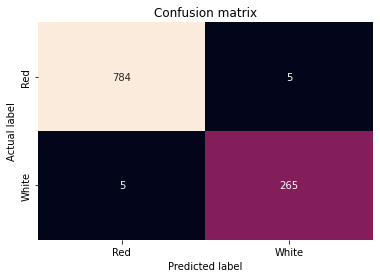


 Classification Report :
--------------------------------------------------
              precision    recall  f1-score   support

         Red       0.99      0.99      0.99       789
       White       0.98      0.98      0.98       270

    accuracy                           0.99      1059
   macro avg       0.99      0.99      0.99      1059
weighted avg       0.99      0.99      0.99      1059



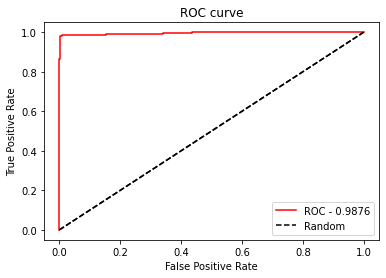

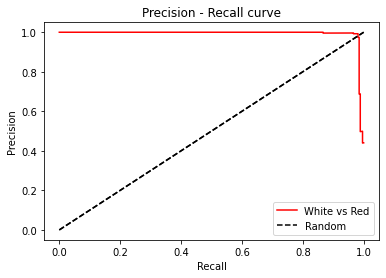

In [ ]:
pipeline = Pipeline(steps=[('columntranformation',column_tranformation),
                          ('scaler',scaler),
                          ('pca',pca),
                          ('xgbclassifier',XGBClassifier(random_state=1,eval_metric='mlogloss'))])

imb_pipeline = make_pipeline(column_tranformation,scaler,pca,over_samp,XGBClassifier(random_state=1,eval_metric='mlogloss'))

param = {'xgbclassifier__n_estimators':[1000],'pca__whiten':[False],
                        'xgbclassifier__max_depth':[2],
#                         'xgbclassifier__learning_rate':[0.1,0.05],
#                         'xgbclassifier__subsample':[1,0.9],
                        'xgbclassifier__reg_lambda':[50]
}

grid = GridSearchCV(estimator=imb_pipeline,
                cv=5,
                param_grid = param,
                verbose=2,
                return_train_score=True,
                n_jobs=-1,
               scoring='accuracy')

grid.fit(X_train,y_train)

set_config(display='diagram')
display(grid.best_estimator_)   

model_metrics(grid,'xgbclassifier')


## Model - 5  Neural Network 

In [ ]:
X_train_scaled = pd.DataFrame(pca.fit_transform(scaler.fit_transform(column_tranformation.fit_transform(X_train))),
                       index=X_train.index,columns=X_train.columns)

X_test_scaled = pd.DataFrame(pca.transform(scaler.transform(column_tranformation.transform(X_test))),
                       index=X_test.index,columns=X_test.columns)

## Oversampled

In [ ]:
X_train_oversampled,y_train_oversampled = over_samp.fit_resample(X_train_scaled,y_train)
X_train_oversampled

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,-0.138796,-0.613680,-0.137709,-0.090754,-0.140247,-0.022383,-0.189038,0.048864,-0.180074,-0.131385,-0.020308,0.008583
1,-0.220673,0.130750,-0.001196,-0.067489,-0.061327,0.117418,-0.035477,-0.099635,0.070566,0.034882,0.030926,-0.029006
2,0.127006,-0.318567,-0.426742,-0.186089,0.014009,0.118257,-0.011771,0.204182,-0.155073,0.083000,-0.030161,-0.025804
3,0.064354,0.037818,-0.126264,0.191685,0.156294,0.069496,-0.192777,0.011937,0.036972,0.063428,-0.018992,0.121647
4,-0.346320,0.563758,0.239368,-0.003028,-0.104640,0.179524,-0.165489,-0.093726,0.016289,-0.086796,0.061264,0.017686
...,...,...,...,...,...,...,...,...,...,...,...,...
6303,0.560864,-0.162058,-0.477285,-0.062230,-0.071008,-0.097001,-0.075069,-0.089632,0.039663,-0.074901,0.106288,0.009080
6304,0.591570,0.149511,-0.533461,0.107627,0.052077,-0.113392,0.117885,0.093106,-0.170155,0.040301,-0.040025,-0.024863
6305,0.216229,0.123227,0.338427,-0.187137,0.051863,0.252329,-0.192386,0.023618,0.154864,0.044295,-0.019241,0.041301
6306,0.586595,0.094089,0.075643,0.016061,0.092071,-0.077678,0.027295,0.023174,-0.125780,-0.065410,-0.048426,-0.034825


Epoch 1/50
158/158 [==============================] - 1s 4ms/step - loss: 0.0768 - accuracy: 0.9820 - val_loss: 0.0099 - val_accuracy: 0.9976
Epoch 2/50
158/158 [==============================] - 0s 2ms/step - loss: 0.0275 - accuracy: 0.9927 - val_loss: 0.0143 - val_accuracy: 0.9960
Epoch 3/50
158/158 [==============================] - 0s 2ms/step - loss: 0.0261 - accuracy: 0.9933 - val_loss: 0.0122 - val_accuracy: 0.9968
Epoch 4/50
158/158 [==============================] - 0s 2ms/step - loss: 0.0271 - accuracy: 0.9946 - val_loss: 0.0185 - val_accuracy: 0.9952
Epoch 5/50
158/158 [==============================] - 0s 2ms/step - loss: 0.0205 - accuracy: 0.9950 - val_loss: 0.0199 - val_accuracy: 0.9960
Epoch 6/50
158/158 [==============================] - 0s 2ms/step - loss: 0.0196 - accuracy: 0.9958 - val_loss: 0.0104 - val_accuracy: 0.9960
Epoch 7/50
158/158 [==============================] - 0s 2ms/step - loss: 0.0236 - accuracy: 0.9950 - val_loss: 0.0084 - val_accuracy: 0.9968
Epoch 

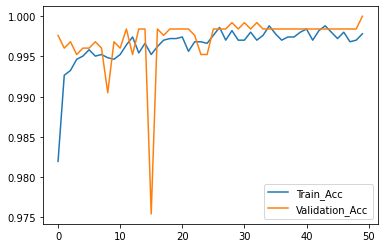

In [ ]:
np.random.seed(1)
set_seed(45)
tf_model = Sequential([Dense(64,activation=tf.nn.relu),
                       Dropout(0.2),
                       Dense(16,activation=tf.nn.relu),
                       Dropout(0.2),
                       Dense(8,activation=tf.nn.relu),
                       Dense(2,activation='softmax')])

tf_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),loss='sparse_categorical_crossentropy',metrics=['accuracy'])


history = tf_model.fit(X_train_oversampled,y_train_oversampled,batch_size=32,epochs=50,validation_split=0.2)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(('Train_Acc','Validation_Acc'))
plt.show()

In [ ]:
predictions = tf_model.predict(X_test_scaled)
y_pred = np.argmax(predictions, axis=1) 
y_pred_prob = predictions

features = X_test.columns

print("Performance Metrics:")
print("-"*50)
print("Accuracy",round(accuracy_score(y_test,y_pred),2))
print("Precision",round(precision_score(y_test,y_pred),2))
print("Recall",round(recall_score(y_test,y_pred),2))

print("\n","Confusion Matrix :")
print("-"*50)
cm = confusion_matrix(y_test,y_pred)
total_classes = len(targets)
codes = [total_classes*[0], list(range(total_classes))]
cm = confusion_matrix(y_test, y_pred)

print("\n","Classification Report :")
print("-"*50)
print(classification_report(y_test,y_pred,target_names=targets))

fig = make_subplots(rows = 2,cols=2,horizontal_spacing=0.15,vertical_spacing=0.12,
                    subplot_titles=("Confusion Matrix","Training vs Validation","ROC - Curve",
                                                                           "Precision - Recall Curve"))

z = [[cm[1,0],cm[1,1]],
          [cm[0,0], cm[0,1]]]

x = ['Predicted - Red', 'Predicted - White']
y = [ 'Actual - White', 'Actual - Red']

fig.add_trace(go.Heatmap(z= z,x=x,y=y,colorscale='oranges',showscale = False,hoverinfo ='none'),row=1,col=1)


fig.add_annotation(dict(x=0.0350, y=0.900, xref="paper", yref="paper", 
                            text=f"True Negative {cm[0,0]}",font=dict(
        family="sans serif",
        size=15,
        color="black"
    ),showarrow=False))
fig.add_annotation(dict(x=0.3350, y=0.900, xref="paper",font=dict(
        family="sans serif",
        size=15,
        color="black"
    ), yref="paper", 
                            text=f"False Positive {cm[0,1]}",showarrow=False))
fig.add_annotation(dict(x=0.0350, y=0.700, xref="paper",font=dict(
        family="sans serif",
        size=15,
        color="black"
    ), yref="paper", 
                            text=f"False Negative {cm[1,0]}",showarrow=False))
fig.add_annotation(dict(x=0.3350, y=0.700, xref="paper", yref="paper", 
                            text=f"True Postive {cm[1,1]}",font=dict(
        family="sans serif",
        size=15,
        color="black"
    ),showarrow=False))


fig.add_trace(go.Scatter(x=list(range(1,51,1)),y=history.history['accuracy'],line ={'color' : 'blue'}),row=1,col=2)
fig.add_trace(go.Scatter(x=list(range(1,51,1)),y=history.history['val_accuracy'],line ={'dash':'dash','color' : 'orange'}),row=1,col=2)
fig.update_xaxes(title_text="Epochs",row=1, col=2)
fig.update_yaxes(title_text="Accuracy",row=1, col=2)


fpr, tpr, thresh = roc_curve(y_test, y_pred_prob[:,1],pos_label=1)
fig.add_trace(go.Scatter(x=fpr,y=tpr,hovertext = np.round(thresh,3),line ={'color' : 'orangered'}),row=2,col=1)
fig.add_trace(go.Scatter(x=[0,1],y=[0,1],line ={'dash':'dash','color' : 'black'}),row=2,col=1)
fig.update_xaxes(title_text="False Positive Rate",row=2, col=1)
fig.update_yaxes(title_text="True Positive Rate",row=2, col=1)
# fig.update_traces(showlegend = False)
fig.add_annotation(dict(x=0.175, y=0.05, xref="paper", yref="paper", 
                        text=f"ROC - {round(roc_auc_score(y_test,y_pred),4)}",font=dict(
    family="sans serif",
    size=15,
    color="black"
),showarrow=False))


pre,rec,thresh = precision_recall_curve(y_test, y_pred_prob[:,1],pos_label=1) 
fig.add_trace(go.Scatter(x=rec,y=pre,hovertext = np.round(thresh,3),line ={'color' : 'orangered'}),row=2,col=2)
fig.add_trace(go.Scatter(x=[0,1],y=[0,1],line ={'dash':'dash','color' : 'black'}),row=2,col=2)
fig.update_xaxes(title_text="Recall",row=2, col=2)
fig.update_yaxes(title_text="Precision",row=2, col=2)
# fig.update_traces(showlegend = False)

fig.add_annotation(dict(x=0.850, y=0.05, xref="paper", yref="paper", 
                        text=f"White vs Red",font=dict(
    family="sans serif",
    size=15,
    color="black"
),showarrow=False))

# fig.update_traces(showlegend = False)
fig.update_layout(height = 700,width = 1000,showlegend = False)
fig.show()

Performance Metrics:
--------------------------------------------------
Accuracy 0.99
Precision 0.99
Recall 0.98

 Confusion Matrix :
--------------------------------------------------

 Classification Report :
--------------------------------------------------
              precision    recall  f1-score   support

         Red       0.99      1.00      1.00       789
       White       0.99      0.98      0.99       270

    accuracy                           0.99      1059
   macro avg       0.99      0.99      0.99      1059
weighted avg       0.99      0.99      0.99      1059



## Imbalanced Data 

In [ ]:
pca = PCA(whiten=True)

In [ ]:
X_train_scaled = pd.DataFrame(pca.fit_transform(scaler.fit_transform(column_tranformation.fit_transform(X_train))),
                       index=X_train.index,columns=X_train.columns)

X_test_scaled = pd.DataFrame(pca.transform(scaler.transform(column_tranformation.transform(X_test))),
                       index=X_test.index,columns=X_test.columns)

In [ ]:
set_seed(1)
tf_model = Sequential([Dense(64,activation=tf.nn.relu),
                       Dropout(0.2),
                       Dense(16,activation=tf.nn.relu),
                       Dropout(0.2),
                       Dense(8,activation=tf.nn.relu),
                       Dense(2,activation='softmax')])

tf_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),loss='sparse_categorical_crossentropy',metrics=['accuracy'])



neg = (len(y_train)-y_train.sum())
pos = y_train.sum()
total = len(y_train)
weight_for_0 = (1 / neg) * (total / 2.0)
weight_for_1 = ((1 / pos) * (total / 2.0))

class_weight = {0: weight_for_0, 1: weight_for_1}
class_weight

{0: 0.6715282181357007, 1: 1.9574861367837337}

In [ ]:
history = tf_model.fit(X_train_scaled,y_train,batch_size=32,epochs=50,validation_split=0.2,class_weight=class_weight)

Epoch 1/50
106/106 [==============================] - 1s 4ms/step - loss: 0.1522 - accuracy: 0.9392 - val_loss: 0.0159 - val_accuracy: 0.9929
Epoch 2/50
106/106 [==============================] - 0s 3ms/step - loss: 0.0489 - accuracy: 0.9911 - val_loss: 0.0148 - val_accuracy: 0.9976
Epoch 3/50
106/106 [==============================] - 0s 3ms/step - loss: 0.0333 - accuracy: 0.9929 - val_loss: 0.0186 - val_accuracy: 0.9941
Epoch 4/50
106/106 [==============================] - 0s 3ms/step - loss: 0.0323 - accuracy: 0.9926 - val_loss: 0.0108 - val_accuracy: 0.9976
Epoch 5/50
106/106 [==============================] - 0s 3ms/step - loss: 0.0278 - accuracy: 0.9929 - val_loss: 0.0160 - val_accuracy: 0.9953
Epoch 6/50
106/106 [==============================] - 0s 2ms/step - loss: 0.0335 - accuracy: 0.9935 - val_loss: 0.0208 - val_accuracy: 0.9953
Epoch 7/50
106/106 [==============================] - 0s 2ms/step - loss: 0.0294 - accuracy: 0.9920 - val_loss: 0.0109 - val_accuracy: 0.9988
Epoch 

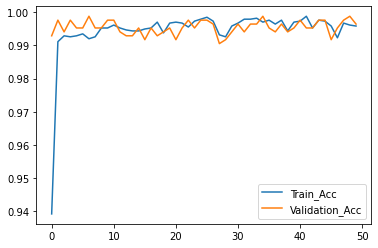

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(('Train_Acc','Validation_Acc'))
plt.show()

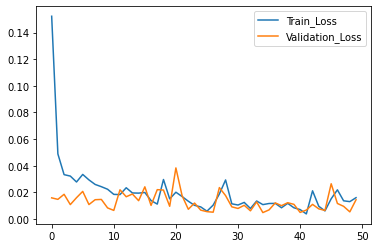

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(('Train_Loss','Validation_Loss'))
plt.show()

In [ ]:
predictions = tf_model.predict(X_test_scaled)
y_pred = np.argmax(predictions, axis=1) 
y_pred_prob = predictions

features = X_test.columns

print("Performance Metrics:")
print("-"*50)
print("Accuracy",round(accuracy_score(y_test,y_pred),2))
print("Precision",round(precision_score(y_test,y_pred),2))
print("Recall",round(recall_score(y_test,y_pred),2))

print("\n","Confusion Matrix :")
print("-"*50)
cm = confusion_matrix(y_test,y_pred)
total_classes = len(targets)
codes = [total_classes*[0], list(range(total_classes))]
cm = confusion_matrix(y_test, y_pred)

print("\n","Classification Report :")
print("-"*50)
print(classification_report(y_test,y_pred,target_names=targets))

fig = make_subplots(rows = 2,cols=2,horizontal_spacing=0.15,vertical_spacing=0.12,
                    subplot_titles=("Confusion Matrix","Training vs Validation","ROC - Curve",
                                                                           "Precision - Recall Curve"))

z = [[cm[1,0],cm[1,1]],
          [cm[0,0], cm[0,1]]]

x = ['Predicted - Red', 'Predicted - White']
y = [ 'Actual - White', 'Actual - Red']

fig.add_trace(go.Heatmap(z= z,x=x,y=y,colorscale='oranges',showscale = False,hoverinfo ='none'),row=1,col=1)


fig.add_annotation(dict(x=0.0350, y=0.900, xref="paper", yref="paper", 
                            text=f"True Negative {cm[0,0]}",font=dict(
        family="sans serif",
        size=15,
        color="black"
    ),showarrow=False))
fig.add_annotation(dict(x=0.3350, y=0.900, xref="paper",font=dict(
        family="sans serif",
        size=15,
        color="black"
    ), yref="paper", 
                            text=f"False Positive {cm[0,1]}",showarrow=False))
fig.add_annotation(dict(x=0.0350, y=0.700, xref="paper",font=dict(
        family="sans serif",
        size=15,
        color="black"
    ), yref="paper", 
                            text=f"False Negative {cm[1,0]}",showarrow=False))
fig.add_annotation(dict(x=0.3350, y=0.700, xref="paper", yref="paper", 
                            text=f"True Postive {cm[1,1]}",font=dict(
        family="sans serif",
        size=15,
        color="black"
    ),showarrow=False))


fig.add_trace(go.Scatter(x=list(range(1,51,1)),y=history.history['accuracy'],line ={'color' : 'blue'}),row=1,col=2)
fig.add_trace(go.Scatter(x=list(range(1,51,1)),y=history.history['val_accuracy'],line ={'dash':'dash','color' : 'orange'}),row=1,col=2)
fig.update_xaxes(title_text="Epochs",row=1, col=2)
fig.update_yaxes(title_text="Accuracy",row=1, col=2)


fpr, tpr, thresh = roc_curve(y_test, y_pred_prob[:,1],pos_label=1)
fig.add_trace(go.Scatter(x=fpr,y=tpr,hovertext = np.round(thresh,3),line ={'color' : 'orangered'}),row=2,col=1)
fig.add_trace(go.Scatter(x=[0,1],y=[0,1],line ={'dash':'dash','color' : 'black'}),row=2,col=1)
fig.update_xaxes(title_text="False Positive Rate",row=2, col=1)
fig.update_yaxes(title_text="True Positive Rate",row=2, col=1)
# fig.update_traces(showlegend = False)
fig.add_annotation(dict(x=0.175, y=0.05, xref="paper", yref="paper", 
                        text=f"ROC - {round(roc_auc_score(y_test,y_pred),4)}",font=dict(
    family="sans serif",
    size=15,
    color="black"
),showarrow=False))


pre,rec,thresh = precision_recall_curve(y_test, y_pred_prob[:,1],pos_label=1) 
fig.add_trace(go.Scatter(x=rec,y=pre,hovertext = np.round(thresh,3),line ={'color' : 'orangered'}),row=2,col=2)
fig.add_trace(go.Scatter(x=[0,1],y=[0,1],line ={'dash':'dash','color' : 'black'}),row=2,col=2)
fig.update_xaxes(title_text="Recall",row=2, col=2)
fig.update_yaxes(title_text="Precision",row=2, col=2)
# fig.update_traces(showlegend = False)

fig.add_annotation(dict(x=0.850, y=0.05, xref="paper", yref="paper", 
                        text=f"White vs Red",font=dict(
    family="sans serif",
    size=15,
    color="black"
),showarrow=False))


fig.update_layout(height = 800,width = 1000,showlegend = False)
fig.show()

Performance Metrics:
--------------------------------------------------
Accuracy 0.99
Precision 0.99
Recall 0.98

 Confusion Matrix :
--------------------------------------------------

 Classification Report :
--------------------------------------------------
              precision    recall  f1-score   support

         Red       0.99      1.00      0.99       789
       White       0.99      0.98      0.98       270

    accuracy                           0.99      1059
   macro avg       0.99      0.99      0.99      1059
weighted avg       0.99      0.99      0.99      1059



# AdaboostClassifier

Fitting 5 folds for each of 1 candidates, totalling 5 fits


Pipeline(steps=[('columntranformation',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric_imputer',
                                                  KNNImputer(),
                                                  Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')),
                                                 ('categorical_transformation',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cat_encoding',
                                                                   OneHotEncoder(drop='first'))]),
                                                  Index([], dtype='object'))])),
                ('scaler', MinMaxScaler()), ('pca', PCA(whiten=True)),
                ('adaboostclassifier',
                 AdaBoostClassifier(learning_rate=0.05, n_estimators=1000,
                                    random_state=1))])



Best Accuracy:
--------------------------------------------------


,param_adaboostclassifier__algorithm,param_adaboostclassifier__learning_rate,param_adaboostclassifier__n_estimators,param_pca__whiten,params,mean_train_score,mean_test_score
0,SAMME.R,0.05,1000,True,"{'adaboostclassifier__algorithm': 'SAMME.R', '...",0.997521,0.993627






Best Parameters:
--------------------------------------------------
{'adaboostclassifier__algorithm': 'SAMME.R', 'adaboostclassifier__learning_rate': 0.05, 'adaboostclassifier__n_estimators': 1000, 'pca__whiten': True}


Performance Metrics:
--------------------------------------------------
Accuracy 0.99
Precision 0.99
Recall 0.97

 Confusion Matrix :
--------------------------------------------------


array([[787,   2],
       [  7, 263]])

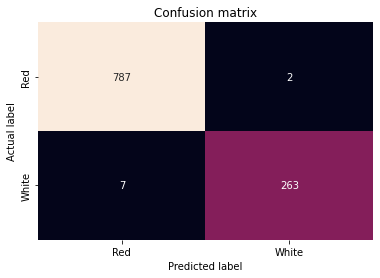


 Classification Report :
--------------------------------------------------
              precision    recall  f1-score   support

         Red       0.99      1.00      0.99       789
       White       0.99      0.97      0.98       270

    accuracy                           0.99      1059
   macro avg       0.99      0.99      0.99      1059
weighted avg       0.99      0.99      0.99      1059



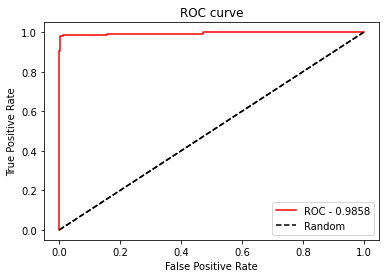

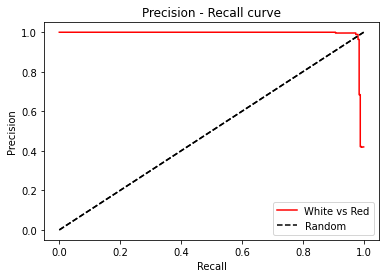

In [ ]:
pipeline = Pipeline(steps=[('columntranformation',column_tranformation),
                          ('scaler',scaler),
                          ('pca',pca),
                          ('adaboostclassifier',AdaBoostClassifier(random_state=1))])

imb_pipeline = make_pipeline(column_tranformation,scaler,pca,over_samp,AdaBoostClassifier(random_state=1))

param ={'adaboostclassifier__n_estimators': [1000], 'pca__whiten':[True],
        'adaboostclassifier__learning_rate': [0.05], 
        'adaboostclassifier__algorithm': ['SAMME.R']}


grid = GridSearchCV(estimator=pipeline,
                cv=5,
                param_grid = param,
                verbose=2,
                return_train_score=True,
                n_jobs=-1,
               scoring='accuracy')

# set_config(display='diagram')
# display(grid)

grid.fit(X_train,y_train)

set_config(display='diagram')
display(grid.best_estimator_)   

model_metrics(grid,'adaboostclassifier')

Fitting 5 folds for each of 1 candidates, totalling 5 fits


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric_imputer',
                                                  KNNImputer(),
                                                  Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')),
                                                 ('categorical_transformation',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cat_encoding',
                                                                   OneHotEncoder(drop='first'))]),
                                                  Index([], dtype='object'))])),
                ('minmaxscaler', MinMaxScaler()), ('pca', PCA()),
                ('smote',
                 SMOTE(k_neighbors=7, random_state=1,
                       sampling_strategy='minority')),
                ('adaboostclassifier',
                 AdaBoostClassifier(learning_rate=0.1, n_estimators=1000,
                                    random_state=1))])



Best Accuracy:
--------------------------------------------------


,param_adaboostclassifier__algorithm,param_adaboostclassifier__learning_rate,param_adaboostclassifier__n_estimators,param_pca__whiten,param_smote__k_neighbors,params,mean_train_score,mean_test_score
0,SAMME.R,0.1,1000,False,7,"{'adaboostclassifier__algorithm': 'SAMME.R', '...",0.999351,0.995043






Best Parameters:
--------------------------------------------------
{'adaboostclassifier__algorithm': 'SAMME.R', 'adaboostclassifier__learning_rate': 0.1, 'adaboostclassifier__n_estimators': 1000, 'pca__whiten': False, 'smote__k_neighbors': 7}


Performance Metrics:
--------------------------------------------------
Accuracy 0.99
Precision 0.99
Recall 0.98

 Confusion Matrix :
--------------------------------------------------


array([[786,   3],
       [  5, 265]])

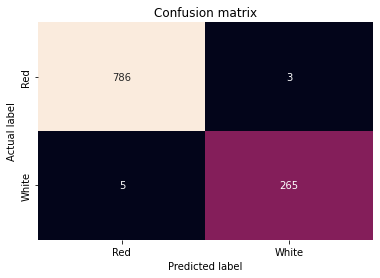


 Classification Report :
--------------------------------------------------
              precision    recall  f1-score   support

         Red       0.99      1.00      0.99       789
       White       0.99      0.98      0.99       270

    accuracy                           0.99      1059
   macro avg       0.99      0.99      0.99      1059
weighted avg       0.99      0.99      0.99      1059



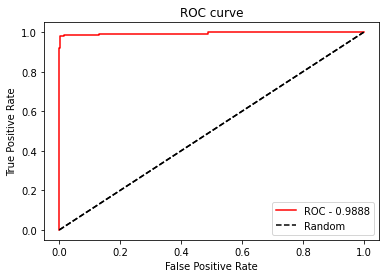

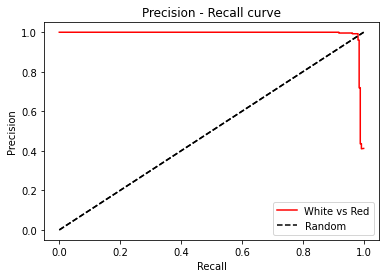

In [ ]:
pipeline = Pipeline(steps=[('columntranformation',column_tranformation),
                          ('scaler',scaler),
                          ('pca',pca),
                          ('adaboostclassifier',AdaBoostClassifier(random_state=1))])

imb_pipeline = make_pipeline(column_tranformation,scaler,pca,over_samp,AdaBoostClassifier(random_state=1))

param ={'adaboostclassifier__n_estimators': [1000], 'pca__whiten':[False],'smote__k_neighbors':[7],
        'adaboostclassifier__learning_rate': [0.1], 
        'adaboostclassifier__algorithm': [ 'SAMME.R']}


grid = GridSearchCV(estimator=imb_pipeline,
                cv=5,
                param_grid = param,
                verbose=2,
                return_train_score=True,
                n_jobs=-1,
               scoring='accuracy')

# set_config(display='diagram')
# display(grid)

grid.fit(X_train,y_train)

set_config(display='diagram')
display(grid.best_estimator_)   

model_metrics(grid,'adaboostclassifier')

# Gradient boost Classifier

Fitting 5 folds for each of 1 candidates, totalling 5 fits


Pipeline(steps=[('columntranformation',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric_imputer',
                                                  KNNImputer(),
                                                  Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')),
                                                 ('categorical_transformation',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cat_encoding',
                                                                   OneHotEncoder(drop='first'))]),
                                                  Index([], dtype='object'))])),
                ('scaler', MinMaxScaler()), ('pca', PCA(whiten=True)),
                ('gradientboostingclassifier',
                 GradientBoostingClassifier(learning_rate=0.05,
                                            n_estimators=900, random_state=1,
                                            subsample=0.9))])



Best Accuracy:
--------------------------------------------------


,param_gradientboostingclassifier__learning_rate,param_gradientboostingclassifier__max_depth,param_gradientboostingclassifier__n_estimators,param_gradientboostingclassifier__subsample,param_pca__whiten,params,mean_train_score,mean_test_score
0,0.05,3,900,0.9,True,{'gradientboostingclassifier__learning_rate': ...,0.999823,0.993391






Best Parameters:
--------------------------------------------------
{'gradientboostingclassifier__learning_rate': 0.05, 'gradientboostingclassifier__max_depth': 3, 'gradientboostingclassifier__n_estimators': 900, 'gradientboostingclassifier__subsample': 0.9, 'pca__whiten': True}


Performance Metrics:
--------------------------------------------------
Accuracy 0.99
Precision 0.99
Recall 0.98

 Confusion Matrix :
--------------------------------------------------


array([[787,   2],
       [  5, 265]])

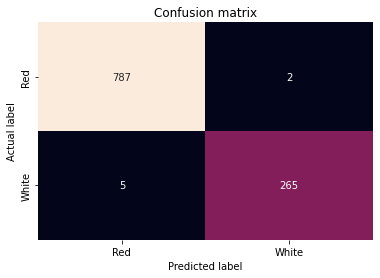


 Classification Report :
--------------------------------------------------
              precision    recall  f1-score   support

         Red       0.99      1.00      1.00       789
       White       0.99      0.98      0.99       270

    accuracy                           0.99      1059
   macro avg       0.99      0.99      0.99      1059
weighted avg       0.99      0.99      0.99      1059



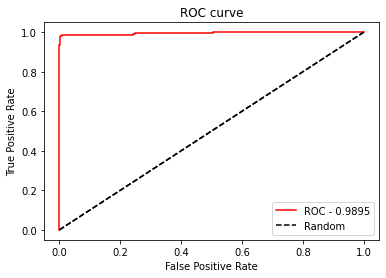

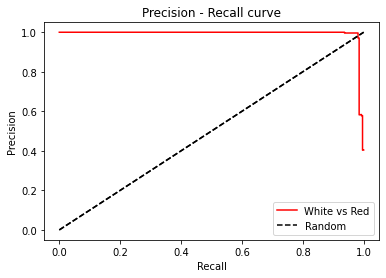

In [ ]:
pipeline = Pipeline(steps=[('columntranformation',column_tranformation),
                          ('scaler',scaler),
                          ('pca',pca),
                          ('gradientboostingclassifier',GradientBoostingClassifier(random_state=1))])

imb_pipeline = make_pipeline(column_tranformation,scaler,pca,over_samp,GradientBoostingClassifier(random_state=1))

param ={'gradientboostingclassifier__n_estimators':[900],'pca__whiten':[True],
                        'gradientboostingclassifier__max_depth':[3],
                        'gradientboostingclassifier__learning_rate':[0.05],
                        'gradientboostingclassifier__subsample':[0.9]}


grid = GridSearchCV(estimator=pipeline,
                cv=5,
                param_grid = param,
                verbose=2,
                return_train_score=True,
                n_jobs=-1,
               scoring='accuracy')

grid.fit(X_train,y_train)

set_config(display='diagram')
display(grid.best_estimator_)   

model_metrics(grid,'gradientboostingclassifier')

Fitting 5 folds for each of 1 candidates, totalling 5 fits


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric_imputer',
                                                  KNNImputer(),
                                                  Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')),
                                                 ('categorical_transformation',...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cat_encoding',
                                                                   OneHotEncoder(drop='first'))]),
                                                  Index([], dtype='object'))])),
                ('minmaxscaler', MinMaxScaler()), ('pca', PCA()),
                ('smote',
                 SMOTE(k_neighbors=2, random_state=1,
                       sampling_strategy='minority')),
                ('gradientboostingclassifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=300,
                                            random_state=1, subsample=0.9))])



Best Accuracy:
--------------------------------------------------


,param_gradientboostingclassifier__learning_rate,param_gradientboostingclassifier__max_depth,param_gradientboostingclassifier__n_estimators,param_gradientboostingclassifier__subsample,param_pca__whiten,param_smote__k_neighbors,params,mean_train_score,mean_test_score
0,0.1,4,300,0.9,False,2,{'gradientboostingclassifier__learning_rate': ...,0.999823,0.992683






Best Parameters:
--------------------------------------------------
{'gradientboostingclassifier__learning_rate': 0.1, 'gradientboostingclassifier__max_depth': 4, 'gradientboostingclassifier__n_estimators': 300, 'gradientboostingclassifier__subsample': 0.9, 'pca__whiten': False, 'smote__k_neighbors': 2}


Performance Metrics:
--------------------------------------------------
Accuracy 0.99
Precision 0.99
Recall 0.98

 Confusion Matrix :
--------------------------------------------------


array([[786,   3],
       [  5, 265]])

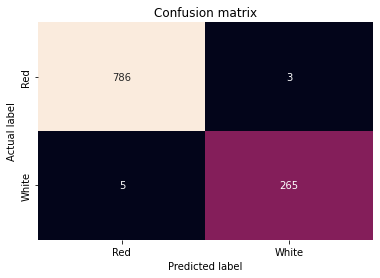


 Classification Report :
--------------------------------------------------
              precision    recall  f1-score   support

         Red       0.99      1.00      0.99       789
       White       0.99      0.98      0.99       270

    accuracy                           0.99      1059
   macro avg       0.99      0.99      0.99      1059
weighted avg       0.99      0.99      0.99      1059



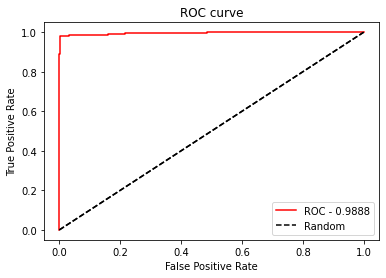

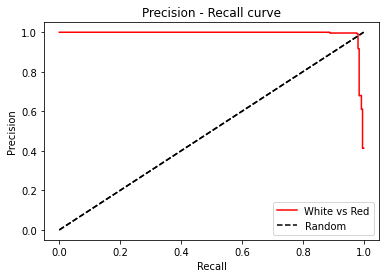

{'gradientboostingclassifier__learning_rate': 0.1,
 'gradientboostingclassifier__max_depth': 4,
 'gradientboostingclassifier__n_estimators': 300,
 'gradientboostingclassifier__subsample': 0.9}

In [ ]:
pipeline = Pipeline(steps=[('columntranformation',column_tranformation),
                          ('scaler',scaler),
                          ('pca',pca),
                          ('gradientboostingclassifier',GradientBoostingClassifier(random_state=1))])

imb_pipeline = make_pipeline(column_tranformation,scaler,pca,over_samp,GradientBoostingClassifier(random_state=1))

param ={'gradientboostingclassifier__n_estimators':[300],'pca__whiten':[False],'smote__k_neighbors':[2],
                        'gradientboostingclassifier__max_depth':[4],
                        'gradientboostingclassifier__learning_rate':[0.1],
                        'gradientboostingclassifier__subsample':[0.9]}



# {'gradientboostingclassifier__learning_rate': [0.1], 
#         'gradientboostingclassifier__max_depth': [6], 
#         'gradientboostingclassifier__n_estimators': [300], 
#         'gradientboostingclassifier__subsample': [0.9]}


grid = GridSearchCV(estimator=imb_pipeline,
                cv=5,
                param_grid = param,
                verbose=2,
                return_train_score=True,
                n_jobs=-1,
               scoring='accuracy')

grid.fit(X_train,y_train)

set_config(display='diagram')
display(grid.best_estimator_)   

model_metrics(grid,'gradientboostingclassifier')

{'gradientboostingclassifier__learning_rate': 0.1, 'gradientboostingclassifier__max_depth': 4, 'gradientboostingclassifier__n_estimators': 300, 'gradientboostingclassifier__subsample': 0.9}


---

# Classification by Quality

In [ ]:
wine.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,Type,quality,discrete_quality
0,0.730188,-0.035906,0.000000,0.715682,-4.595977,5.398421,31.99840,-0.002640,3.580179,-0.436606,0.586807,White,5,Low
1,NaN,-1.077738,0.630032,0.751982,-4.489630,2.718778,17.99910,0.000299,3.160158,-0.833117,0.585241,White,5,Low
2,0.717377,-1.582138,0.490025,1.566687,-7.029059,10.685322,205.98970,-0.004822,3.240162,-1.014864,0.584471,Red,6,Medium
3,0.730188,-2.115251,0.300015,1.885503,-6.431593,10.191881,228.98855,-0.001535,3.140157,-0.833117,0.584200,Red,7,Medium
4,0.714249,-1.259880,0.300015,1.808788,-6.935709,7.528144,236.98815,-0.002062,3.180159,-0.833117,0.583029,Red,5,Low


In [ ]:
y = wine[['discrete_quality']]
X = wine.drop(['quality','discrete_quality'],axis = 1)

In [ ]:
ord_encoder = OrdinalEncoder()
y = ord_encoder.fit_transform(y)
y

array([[1.],
       [1.],
       [2.],
       ...,
       [1.],
       [1.],
       [2.]])

In [ ]:
ord_encoder.inverse_transform(y)

array([['Low'],
       ['Low'],
       ['Medium'],
       ...,
       ['Low'],
       ['Low'],
       ['Medium']], dtype=object)

In [ ]:
targets = list(ord_encoder.categories_[0])
targets

['High', 'Low', 'Medium']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,stratify=y,test_size=0.2,random_state=1)

print("Train Shape :",X_train.shape)
print("Test Shape :",X_test.shape)

Train Shape : (4236, 12)
Test Shape : (1059, 12)


## <font color = 'red'> Defining a pipeline

## Step - 1 Column Transformer

In [ ]:
# Numeric columns 
num_cols = X_train.select_dtypes(exclude = 'object').columns
cat_cols = X_train.select_dtypes(include= 'object').columns

# Numeric Preprocessing
num_imputer = KNNImputer(n_neighbors=5)


# Categorical Preprocessing
cat_imputer = SimpleImputer(strategy='most_frequent')
cat_encoder = OneHotEncoder(drop='first')

# Defining Categorical Pipeline
cat_pipeline = Pipeline(steps=[('cat_imputer',cat_imputer),
                              ('cat_encoding',cat_encoder)])

# Defininh column Transformer
column_tranformation = ColumnTransformer(transformers=[('numeric_imputer',num_imputer,num_cols),
                                        ('categorical_transformation',cat_pipeline,cat_cols)],
                                        remainder='passthrough',verbose=False)

## Step - 2 Scaling

In [ ]:
scaler = MinMaxScaler()

## Step - 3 PCA

In [ ]:
# PCA 
comp = len(num_cols)+sum([len(X_train[i].unique()) for i in cat_cols])-len(cat_cols)
pca = PCA(n_components=comp)

## Step - 4 SMOTE

In [ ]:
# SMOTE
over_samp = SMOTE(sampling_strategy='minority',random_state=1)

## Step - 5 Model

In [ ]:
# models_dict = {"Log_clf": LogisticRegression(random_state=1),
#               "dt_clf":DecisionTreeClassifier(random_state=1),
#               "rf_clf":RandomForestClassifier(random_state=1),
#               "xgb_clf":XGBClassifier(random_state=1),
#               "knn_clf":KNeighborsClassifier(),
#               "ada_clf":AdaBoostClassifier(random_state = 1)}


m = LogisticRegression(random_state=1)

# PCA and WHY PCA is required ? 

Principal component analysis (PCA) is one of a family of techniques for taking high-dimensional data, and using the dependencies between the variables to represent it in a more tractable, lower-dimensional basis, without losing too much information.
It is Statistical procedure to convert observations of possibly correlated variables into 'Principal Components' that are:
- Independent of each other (Uncorrelated)
- That Captures maximum information in first few components

- **UseCases** :
    - Dimensionality reduction
    - Data visualization and Exploratory Data Analysis
    - Create uncorrelated features/variables that can be an input to a prediction model
    - Uncovering latent variables/themes/concepts
    - Noise reduction in the dataset

In [ ]:
pca_pipeline = Pipeline(steps = [("ct",column_tranformation),('sclaer',scaler),('pca',pca)])
pc_df = pd.DataFrame(pca_pipeline.fit_transform(X_train),columns = ['PC'+str(i) for i in range(1,13)],index = X_train.index)
pc_df = pc_df.iloc[:,0:3]
labels = pd.DataFrame(ord_encoder.inverse_transform(y_train),index = X_train.index,columns = ['discrete_quality'])
full_df = pd.concat([pc_df,labels],axis = 1)

In [ ]:
fig = ex.scatter_3d(full_df, x='PC1', y='PC2', z='PC3',
          color='discrete_quality',opacity=0.7)

fig.update_layout(width = 800,height = 500,title = "Visualizing the Quality of wine - 3D",title_x = 0.5,title_y = 0.95)

fig.show()

In [ ]:
fig = ex.scatter(full_df, x='PC1', y='PC2',
          color='discrete_quality',opacity=0.7)

fig.update_layout(width = 800,height = 500,title = "Visualizing the Quality of wine - 2D",title_x = 0.5,title_y = 0.95)

fig.show()

- ### Why Scaling is required before PCA or Model Building ?
    - Many machine learning algorithms perform better or converge faster when features are on a relatively similar scale and/or close to normally distributed.

    - Machine learning algorithm just sees number , if there is a vast difference in the range say few ranging in thousands and few ranging in the tens, and it makes the underlying assumption that higher ranging numbers have superiority of some sort.

#### PCA with out scaling

In [ ]:
pca_pipeline = Pipeline(steps = [("ct",column_tranformation),('pca',pca)])
pc_df = pd.DataFrame(pca_pipeline.fit_transform(X_train),columns = ['PC'+str(i) for i in range(1,13)],index = X_train.index)
pc_df = pc_df.iloc[:,0:3]
labels = pd.DataFrame(ord_encoder.inverse_transform(y_train),index = X_train.index,columns = ['discrete_quality'])
full_df = pd.concat([pc_df,labels],axis = 1)

In [ ]:
fig = ex.scatter(full_df, x='PC1', y='PC2',
          color='discrete_quality',opacity=0.7)

fig.update_layout(width = 800,height = 500,title = "Visualizing the Quality of wine - 2D",title_x = 0.5,title_y = 0.95)

fig.show()

### How to Handle Imbalanced classes ? 

- Most machine learning algorithms work best when the number of samples in each class are about equal. This is because most algorithms are designed to maximize accuracy and reduce errors.
- However, if the data set in imbalance then In such cases, you get a **pretty high accuracy just by predicting the majority class, but you fail to capture the minority class**, which is most often the point of creating the model in the first place.

### Oversampling Minority Classes

- **SMOTE** is an oversampling technique where the synthetic samples are generated for the minority class. This algorithm helps to overcome the overfitting problem posed by random oversampling. It focuses on the feature space to generate new instances with the help of interpolation between the positive instances that lie together.

In [ ]:
pca_pipeline = make_pipeline(column_tranformation,scaler,pca,over_samp)
ox,oy = pca_pipeline.fit_resample(X_train,y_train)
pc_df = pd.DataFrame(ox,columns = ['PC'+str(i) for i in range(1,13)])
pc_df = pc_df.iloc[:,0:3]
labels = pd.DataFrame(ord_encoder.inverse_transform(oy.reshape(-1,1)),columns = ['discrete_quality'])
full_df = pd.concat([pc_df,labels],axis = 1)

In [ ]:
fig = ex.scatter(full_df, x='PC1', y='PC2',
          color='discrete_quality',opacity=0.7)

fig.update_layout(width = 800,height = 500,title = "Visualizing the Quality of wine - 2D",title_x = 0.5,title_y = 0.95)

fig.show()

---

In [ ]:
def model_metrics_mul(grid,model_type,X_test = X_test,y_test = y_test,targets = targets):
    
    print("\n")
    print("Best Accuracy:")
    print('-'*50)
    results = pd.DataFrame(grid.cv_results_)
    sel_cols = [i for i in results if i.find('param') != -1]
    sel_cols.extend(['mean_train_score','mean_test_score'])
    results = results.loc[:,sel_cols]
    display(results[results.params == grid.best_params_])
    print("\n")
    
    print("\n")
    print("Best Parameters:")
    print('-'*50)
    print(grid.best_params_)
    print("\n")

    y_pred = grid.predict(X_test)
    y_pred_prob = grid.predict_proba(X_test)

    features = X_test.columns

    print("Performance Metrics:")
    print("-"*50)
    print("Accuracy",round(accuracy_score(y_test,y_pred),2))
#     print("Precision",round(precision_score(y_test,y_pred),2))
#     print("Recall",round(recall_score(y_test,y_pred),2))

    print("\n","Confusion Matrix :")
    print("-"*50)
    cm = confusion_matrix(y_test,y_pred)
    total_classes = len(targets)
    codes = [total_classes*[0], list(range(total_classes))]
    cm = confusion_matrix(y_test, y_pred)

    display(cm)
    sns.heatmap(cm,annot=True,fmt="d",cbar = False)
    plt.xticks([0.5,1.5,2.5],labels=targets)
    plt.yticks([0.5,1.5,2.5],labels=targets)
    plt.title('Confusion matrix')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.show()

    print("\n","Classification Report :")
    print("-"*50)
    print(classification_report(y_test,y_pred,target_names=targets))

    fpr = {}
    tpr = {}
    thresh ={}

    for i in range(len(targets)):    
        fpr[i], tpr[i], thresh[i] = roc_curve(y_test, y_pred_prob[:,i], pos_label=i)
    
    # plotting    
    plt.plot(fpr[0], tpr[0],color='red', label='High vs Rest')
    plt.plot(fpr[1], tpr[1],color='green', label='Low vs Rest')
    plt.plot(fpr[2], tpr[2],color='blue', label='Medium vs Rest')
    plt.plot([(0,0),(1,1)],linestyle = "--",color = "black")
    plt.title('ROC curve')
    plt.legend((f"ROC ['High vs Rest']",
                f"ROC ['Low vs Rest']",
                f"ROC ['Medium vs Rest']",
                "Random"))
    plt.xlabel('False Positive Rate')
    plt.ylabel("True Positive Rate")
    plt.show()
    
    pre = {}
    rec = {}
    thresh1 ={}

    for i in range(len(targets)):    
        pre[i], rec[i], thresh1[i] = precision_recall_curve(y_test, y_pred_prob[:,i], pos_label=i)
    
    # plotting    
    plt.plot(pre[0], rec[0],color='red', label='High vs Rest')
    plt.plot(pre[1], rec[1],color='green', label='Low vs Rest')
    plt.plot(pre[2], rec[2],color='blue', label='Medium vs Rest')
    plt.plot([(0,0),(1,1)],linestyle = "--",color = "black")
    plt.title('Precision - Recall curve')
    plt.legend((f"PR ['High vs Rest']",
                f"PR ['Low vs Rest']",
                f"PR ['Medium vs Rest']",
                "Random"))    
    plt.xlabel('Recall')
    plt.ylabel("Precision")
    plt.show()
    

#     try:        
#         # Variable importance
#         importance = pd.DataFrame({'features': features,'importance': grid.best_estimator_.named_steps[model_type].feature_importances_})
#         importance.index=importance.features
#         importance.sort_values(by='importance', ascending=True).plot.barh()
#         plt.legend(loc='lower right')
#         plt.title("Feature Importance Plot")
#         plt.show()
#     except:
#         importance = pd.DataFrame(grid.best_estimator_.named_steps[model_type].coef_).T
#         importance.columns = targets
#         importance.index = features
#         importance.sort_values(by=targets, ascending=True).plot.barh()
#         plt.legend(loc='lower right')
#         plt.title("Feature Importance Plot")
#         plt.show() 

# Model - Logistic Regression

Fitting 5 folds for each of 1 candidates, totalling 5 fits


Pipeline(steps=[('columntranformation',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric_imputer',
                                                  KNNImputer(),
                                                  Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')),
                                                 ('categorical_transformation',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cat_encoding',
                                                                   OneHotEncoder(drop='first'))]),
                                                  Index(['Type'], dtype='object'))])),
                ('scaler', MinMaxScaler()), ('pca', PCA(n_components=12)),
                ('logisticregression',
                 LogisticRegression(class_weight='balanced', random_state=1,
                                    solver='liblinear', tol=0.01))])



Best Accuracy:
--------------------------------------------------


,param_logisticregression__C,param_logisticregression__class_weight,param_logisticregression__penalty,param_logisticregression__solver,param_logisticregression__tol,param_pca__whiten,params,mean_train_score,mean_test_score
0,1,balanced,l2,liblinear,0.01,False,"{'logisticregression__C': 1.0, 'logisticregres...",0.71754,0.713171






Best Parameters:
--------------------------------------------------
{'logisticregression__C': 1.0, 'logisticregression__class_weight': 'balanced', 'logisticregression__penalty': 'l2', 'logisticregression__solver': 'liblinear', 'logisticregression__tol': 0.01, 'pca__whiten': False}


Performance Metrics:
--------------------------------------------------
Accuracy 0.73

 Confusion Matrix :
--------------------------------------------------


array([[  2,   1,  28],
       [  0, 290, 104],
       [  5, 151, 478]])

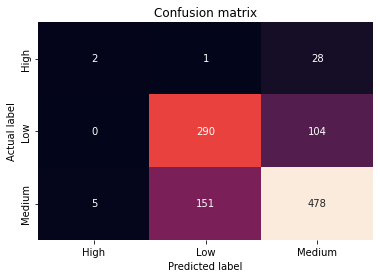


 Classification Report :
--------------------------------------------------
              precision    recall  f1-score   support

        High       0.29      0.06      0.11        31
         Low       0.66      0.74      0.69       394
      Medium       0.78      0.75      0.77       634

    accuracy                           0.73      1059
   macro avg       0.58      0.52      0.52      1059
weighted avg       0.72      0.73      0.72      1059



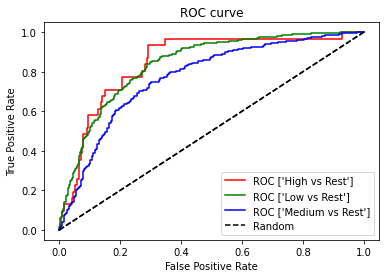

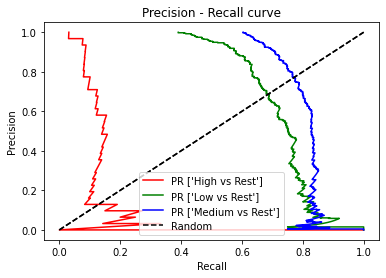

In [ ]:
pipeline = Pipeline(steps=[('columntranformation',column_tranformation),
                          ('scaler',scaler),
                          ('pca',pca),
                          ('logisticregression',m)])

imb_pipeline = make_pipeline(column_tranformation,scaler,pca,over_samp,m)

param = {'pca__whiten':[False],'logisticregression__C': [1.0]
                          ,'logisticregression__solver': ['liblinear'] 
                          ,'logisticregression__penalty': [ 'l2']
                          ,'logisticregression__tol' : [0.01] 
                          ,'logisticregression__class_weight': ['balanced']}

grid = GridSearchCV(estimator=pipeline,
                cv=5,
                param_grid = param,
                verbose=1,
                return_train_score=True,
                n_jobs=-1,
               scoring='accuracy')

grid.fit(X_train,y_train)

set_config(display='diagram')
display(grid.best_estimator_)   

model_metrics_mul(grid,'logisticregression')

Fitting 5 folds for each of 1 candidates, totalling 5 fits


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric_imputer',
                                                  KNNImputer(),
                                                  Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')),
                                                 ('categorical_transformation',
                                                  Pipeline(s...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cat_encoding',
                                                                   OneHotEncoder(drop='first'))]),
                                                  Index(['Type'], dtype='object'))])),
                ('minmaxscaler', MinMaxScaler()),
                ('pca', PCA(n_components=12, whiten=True)),
                ('smote',
                 SMOTE(k_neighbors=7, random_state=1,
                       sampling_strategy='minority')),
                ('logisticregression',
                 LogisticRegression(class_weight='balanced', random_state=1,
                                    tol=0.01))])



Best Accuracy:
--------------------------------------------------


,param_logisticregression__C,param_logisticregression__class_weight,param_logisticregression__penalty,param_logisticregression__solver,param_logisticregression__tol,param_pca__whiten,param_smote__k_neighbors,params,mean_train_score,mean_test_score
0,1,balanced,l2,lbfgs,0.01,True,7,"{'logisticregression__C': 1.0, 'logisticregres...",0.556362,0.553827






Best Parameters:
--------------------------------------------------
{'logisticregression__C': 1.0, 'logisticregression__class_weight': 'balanced', 'logisticregression__penalty': 'l2', 'logisticregression__solver': 'lbfgs', 'logisticregression__tol': 0.01, 'pca__whiten': True, 'smote__k_neighbors': 7}


Performance Metrics:
--------------------------------------------------
Accuracy 0.6

 Confusion Matrix :
--------------------------------------------------


array([[ 22,   1,   8],
       [ 10, 316,  68],
       [164, 177, 293]])

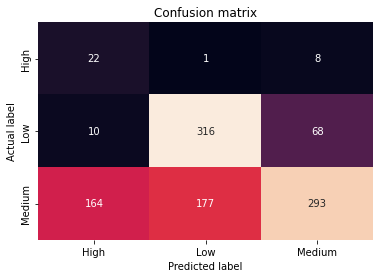


 Classification Report :
--------------------------------------------------
              precision    recall  f1-score   support

        High       0.11      0.71      0.19        31
         Low       0.64      0.80      0.71       394
      Medium       0.79      0.46      0.58       634

    accuracy                           0.60      1059
   macro avg       0.52      0.66      0.50      1059
weighted avg       0.72      0.60      0.62      1059



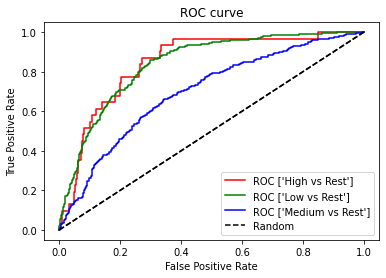

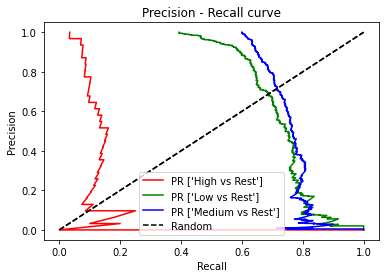

In [ ]:
pipeline = Pipeline(steps=[('columntranformation',column_tranformation),
                          ('scaler',scaler),
                          ('pca',pca),
                          ('logisticregression',m)])

imb_pipeline = make_pipeline(column_tranformation,scaler,pca,over_samp,m)

param = {'pca__whiten':[True],
    'smote__k_neighbors':[7],
    'logisticregression__C': [1.0]
                          ,'logisticregression__solver': ['lbfgs'] 
                          ,'logisticregression__penalty': [ 'l2']
                          ,'logisticregression__tol' : [0.01] 
                          ,'logisticregression__class_weight': ['balanced']}

grid = GridSearchCV(estimator=imb_pipeline,
                cv=5,
                param_grid = param,
                verbose=1,
                return_train_score=True,
                n_jobs=-1,
               scoring='accuracy')

grid.fit(X_train,y_train)

set_config(display='diagram')
display(grid.best_estimator_)   

model_metrics_mul(grid,'logisticregression')


# Decission Tree Classifier

Fitting 5 folds for each of 1 candidates, totalling 5 fits


Pipeline(steps=[('columntranformation',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric_imputer',
                                                  KNNImputer(),
                                                  Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')),
                                                 ('categorical_transformation',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cat_encoding',
                                                                   OneHotEncoder(drop='first'))]),
                                                  Index(['Type'], dtype='object'))])),
                ('scaler', MinMaxScaler()),
                ('pca', PCA(n_components=12, whiten=True)),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(max_depth=4, max_features=8,
                                        min_impurity_decrease=0.01,
                                        random_state=1))])



Best Accuracy:
--------------------------------------------------


,param_decisiontreeclassifier__max_depth,param_decisiontreeclassifier__max_features,param_decisiontreeclassifier__min_impurity_decrease,param_decisiontreeclassifier__min_samples_split,param_pca__whiten,params,mean_train_score,mean_test_score
0,4,8,0.01,2,True,"{'decisiontreeclassifier__max_depth': 4, 'deci...",0.674574,0.656987






Best Parameters:
--------------------------------------------------
{'decisiontreeclassifier__max_depth': 4, 'decisiontreeclassifier__max_features': 8, 'decisiontreeclassifier__min_impurity_decrease': 0.01, 'decisiontreeclassifier__min_samples_split': 2, 'pca__whiten': True}


Performance Metrics:
--------------------------------------------------
Accuracy 0.68

 Confusion Matrix :
--------------------------------------------------


array([[  0,   2,  29],
       [  0, 235, 159],
       [  0, 152, 482]])

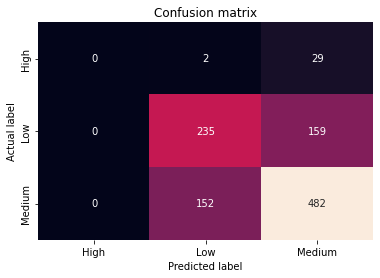


 Classification Report :
--------------------------------------------------
              precision    recall  f1-score   support

        High       0.00      0.00      0.00        31
         Low       0.60      0.60      0.60       394
      Medium       0.72      0.76      0.74       634

    accuracy                           0.68      1059
   macro avg       0.44      0.45      0.45      1059
weighted avg       0.66      0.68      0.67      1059



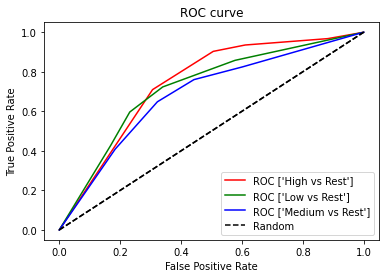

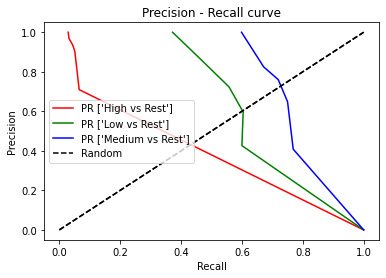

In [ ]:
pipeline = Pipeline(steps=[('columntranformation',column_tranformation),
                          ('scaler',scaler),
                          ('pca',pca),
                          ('decisiontreeclassifier',DecisionTreeClassifier(random_state=1))])

imb_pipeline = make_pipeline(column_tranformation,scaler,pca,over_samp,DecisionTreeClassifier(random_state=1))

param = {'pca__whiten':[True],'decisiontreeclassifier__max_depth':[4],
                       'decisiontreeclassifier__min_samples_split':[2],
                       'decisiontreeclassifier__max_features':[8],
                        'decisiontreeclassifier__min_impurity_decrease':[0.01]}

grid = GridSearchCV(estimator=pipeline,
                cv=5,
                param_grid = param,
                verbose=2,
                return_train_score=True,
                n_jobs=-1,
               scoring='accuracy')

grid.fit(X_train,y_train)

set_config(display='diagram')
display(grid.best_estimator_)   

model_metrics_mul(grid,'decisiontreeclassifier')

In [ ]:
{'decisiontreeclassifier__max_depth': 4, 'decisiontreeclassifier__max_features': 8, 'decisiontreeclassifier__max_leaf_nodes': 10, 'decisiontreeclassifier__min_impurity_decrease': 0.01, 'decisiontreeclassifier__min_samples_split': 2}

{'decisiontreeclassifier__max_depth': 4,
 'decisiontreeclassifier__max_features': 8,
 'decisiontreeclassifier__max_leaf_nodes': 10,
 'decisiontreeclassifier__min_impurity_decrease': 0.01,
 'decisiontreeclassifier__min_samples_split': 2}

Fitting 5 folds for each of 1 candidates, totalling 5 fits


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric_imputer',
                                                  KNNImputer(),
                                                  Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')),
                                                 ('categorical_transformation',
                                                  Pipeline(s...
                                                                  ('cat_encoding',
                                                                   OneHotEncoder(drop='first'))]),
                                                  Index(['Type'], dtype='object'))])),
                ('minmaxscaler', MinMaxScaler()),
                ('pca', PCA(n_components=12, whiten=True)),
                ('smote',
                 SMOTE(k_neighbors=7, random_state=1,
                       sampling_strategy='minority')),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(max_depth=4, max_features=12,
                                        min_impurity_decrease=0.01,
                                        random_state=1))])



Best Accuracy:
--------------------------------------------------


,param_decisiontreeclassifier__max_depth,param_decisiontreeclassifier__max_features,param_decisiontreeclassifier__min_impurity_decrease,param_decisiontreeclassifier__min_samples_split,param_pca__whiten,param_smote__k_neighbors,params,mean_train_score,mean_test_score
0,4,12,0.01,2,True,7,"{'decisiontreeclassifier__max_depth': 4, 'deci...",0.424992,0.413349






Best Parameters:
--------------------------------------------------
{'decisiontreeclassifier__max_depth': 4, 'decisiontreeclassifier__max_features': 12, 'decisiontreeclassifier__min_impurity_decrease': 0.01, 'decisiontreeclassifier__min_samples_split': 2, 'pca__whiten': True, 'smote__k_neighbors': 7}


Performance Metrics:
--------------------------------------------------
Accuracy 0.38

 Confusion Matrix :
--------------------------------------------------


array([[ 26,   4,   1],
       [ 57, 292,  45],
       [298, 249,  87]])

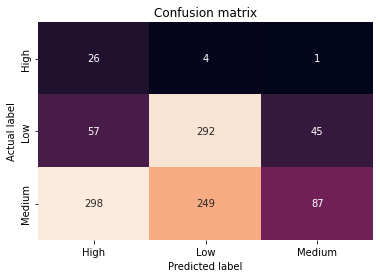


 Classification Report :
--------------------------------------------------
              precision    recall  f1-score   support

        High       0.07      0.84      0.13        31
         Low       0.54      0.74      0.62       394
      Medium       0.65      0.14      0.23       634

    accuracy                           0.38      1059
   macro avg       0.42      0.57      0.33      1059
weighted avg       0.59      0.38      0.37      1059



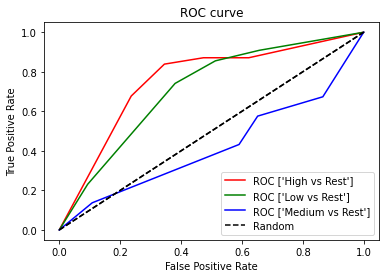

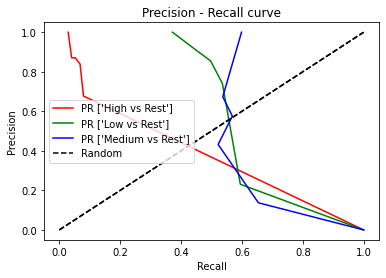

In [ ]:
pipeline = Pipeline(steps=[('columntranformation',column_tranformation),
                          ('scaler',scaler),
                          ('pca',pca),
                          ('decisiontreeclassifier',DecisionTreeClassifier(random_state=1))])

imb_pipeline = make_pipeline(column_tranformation,scaler,pca,over_samp,DecisionTreeClassifier(random_state=1))

param = {'pca__whiten':[True],
    'smote__k_neighbors':[7],
         'decisiontreeclassifier__max_depth':[4],
                       'decisiontreeclassifier__min_samples_split':[2],
                       'decisiontreeclassifier__max_features':[12],
                        'decisiontreeclassifier__min_impurity_decrease':[0.01]}

grid = GridSearchCV(estimator=imb_pipeline,
                cv=5,
                param_grid = param,
                verbose=2,
                return_train_score=True,
                n_jobs=-1,
               scoring='accuracy')

grid.fit(X_train,y_train)

set_config(display='diagram')
display(grid.best_estimator_)   

model_metrics_mul(grid,'decisiontreeclassifier')


# Random forrest

Fitting 5 folds for each of 1 candidates, totalling 5 fits


Pipeline(steps=[('columntranformation',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric_imputer',
                                                  KNNImputer(),
                                                  Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')),
                                                 ('categorical_transformation',
                                                  Pipeline...mputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cat_encoding',
                                                                   OneHotEncoder(drop='first'))]),
                                                  Index(['Type'], dtype='object'))])),
                ('scaler', MinMaxScaler()),
                ('pca', PCA(n_components=12, whiten=True)),
                ('randomforestclassifier',
                 RandomForestClassifier(ccp_alpha=0.001,
                                        class_weight='balanced', max_depth=9,
                                        max_features=7, n_estimators=1000,
                                        random_state=1))])



Best Accuracy:
--------------------------------------------------


,param_pca__whiten,param_randomforestclassifier__ccp_alpha,param_randomforestclassifier__class_weight,param_randomforestclassifier__max_depth,param_randomforestclassifier__max_features,param_randomforestclassifier__min_samples_split,param_randomforestclassifier__n_estimators,params,mean_train_score,mean_test_score
0,True,0.001,balanced,9,7,2,1000,"{'pca__whiten': True, 'randomforestclassifier_...",0.828907,0.707276






Best Parameters:
--------------------------------------------------
{'pca__whiten': True, 'randomforestclassifier__ccp_alpha': 0.001, 'randomforestclassifier__class_weight': 'balanced', 'randomforestclassifier__max_depth': 9, 'randomforestclassifier__max_features': 7, 'randomforestclassifier__min_samples_split': 2, 'randomforestclassifier__n_estimators': 1000}


Performance Metrics:
--------------------------------------------------
Accuracy 0.7

 Confusion Matrix :
--------------------------------------------------


array([[  4,   0,  27],
       [  0, 294, 100],
       [ 29, 157, 448]])

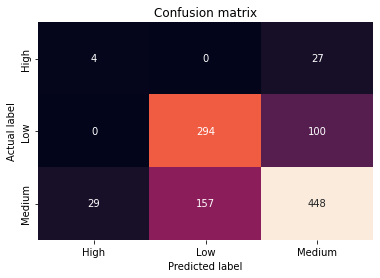


 Classification Report :
--------------------------------------------------
              precision    recall  f1-score   support

        High       0.12      0.13      0.12        31
         Low       0.65      0.75      0.70       394
      Medium       0.78      0.71      0.74       634

    accuracy                           0.70      1059
   macro avg       0.52      0.53      0.52      1059
weighted avg       0.71      0.70      0.71      1059



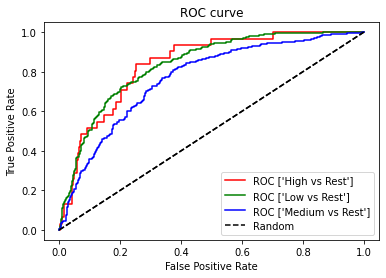

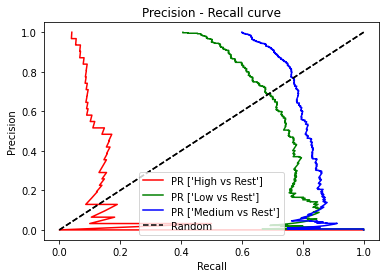

In [ ]:
pipeline = Pipeline(steps=[('columntranformation',column_tranformation),
                          ('scaler',scaler),
                          ('pca',pca),
                          ('randomforestclassifier',RandomForestClassifier(random_state=1))])

imb_pipeline = make_pipeline(column_tranformation,scaler,pca,over_samp,RandomForestClassifier(random_state=1))

param = {'pca__whiten':[True],'randomforestclassifier__n_estimators':[1000],
                        'randomforestclassifier__max_depth':[9],
                       'randomforestclassifier__min_samples_split':[2],
                       'randomforestclassifier__max_features':[7],
                        'randomforestclassifier__ccp_alpha':[0.001],
                        'randomforestclassifier__class_weight':["balanced"]}

grid = GridSearchCV(estimator=pipeline,
                cv=5,
                param_grid = param,
                verbose=2,
                return_train_score=True,
                n_jobs=-1,
               scoring='accuracy')

grid.fit(X_train,y_train)

set_config(display='diagram')
display(grid.best_estimator_)   

model_metrics_mul(grid,'randomforestclassifier')

In [ ]:
'''

{'randomforestclassifier__ccp_alpha': 0.001, 'randomforestclassifier__class_weight': 'balanced_subsample', 'randomforestclassifier__max_depth': 6, 'randomforestclassifier__max_features': 4, 'randomforestclassifier__min_samples_split': 3, 'randomforestclassifier__n_estimators': 100}
{'randomforestclassifier__ccp_alpha': 0.001, 'randomforestclassifier__class_weight': 'balanced_subsample', 'randomforestclassifier__max_depth': 6, 'randomforestclassifier__max_features': 8, 'randomforestclassifier__min_samples_split': 10, 'randomforestclassifier__n_estimators': 400}'''

"\n\n{'randomforestclassifier__ccp_alpha': 0.001, 'randomforestclassifier__class_weight': 'balanced_subsample', 'randomforestclassifier__max_depth': 6, 'randomforestclassifier__max_features': 4, 'randomforestclassifier__min_samples_split': 3, 'randomforestclassifier__n_estimators': 100}\n{'randomforestclassifier__ccp_alpha': 0.001, 'randomforestclassifier__class_weight': 'balanced_subsample', 'randomforestclassifier__max_depth': 6, 'randomforestclassifier__max_features': 8, 'randomforestclassifier__min_samples_split': 10, 'randomforestclassifier__n_estimators': 400}"

Fitting 5 folds for each of 1 candidates, totalling 5 fits


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric_imputer',
                                                  KNNImputer(),
                                                  Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')),
                                                 ('categorical_transformation',
                                                  Pipeline(s...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cat_encoding',
                                                                   OneHotEncoder(drop='first'))]),
                                                  Index(['Type'], dtype='object'))])),
                ('minmaxscaler', MinMaxScaler()), ('pca', PCA(n_components=12)),
                ('smote',
                 SMOTE(k_neighbors=2, random_state=1,
                       sampling_strategy='minority')),
                ('randomforestclassifier',
                 RandomForestClassifier(ccp_alpha=0.001, max_depth=12,
                                        max_features=8, n_estimators=1000,
                                        random_state=1))])



Best Accuracy:
--------------------------------------------------


,param_pca__whiten,param_randomforestclassifier__ccp_alpha,param_randomforestclassifier__class_weight,param_randomforestclassifier__max_depth,param_randomforestclassifier__max_features,param_randomforestclassifier__min_samples_split,param_randomforestclassifier__n_estimators,param_smote__k_neighbors,params,mean_train_score,mean_test_score
0,False,0.001,None,12,8,2,1000,2,"{'pca__whiten': False, 'randomforestclassifier...",0.823773,0.67517






Best Parameters:
--------------------------------------------------
{'pca__whiten': False, 'randomforestclassifier__ccp_alpha': 0.001, 'randomforestclassifier__class_weight': None, 'randomforestclassifier__max_depth': 12, 'randomforestclassifier__max_features': 8, 'randomforestclassifier__min_samples_split': 2, 'randomforestclassifier__n_estimators': 1000, 'smote__k_neighbors': 2}


Performance Metrics:
--------------------------------------------------
Accuracy 0.7

 Confusion Matrix :
--------------------------------------------------


array([[  8,   0,  23],
       [  2, 255, 137],
       [ 56,  96, 482]])

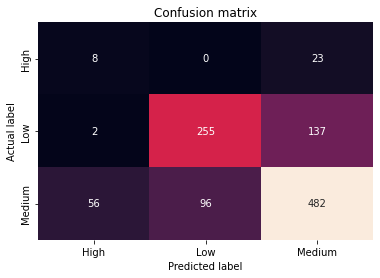


 Classification Report :
--------------------------------------------------
              precision    recall  f1-score   support

        High       0.12      0.26      0.16        31
         Low       0.73      0.65      0.68       394
      Medium       0.75      0.76      0.76       634

    accuracy                           0.70      1059
   macro avg       0.53      0.56      0.53      1059
weighted avg       0.72      0.70      0.71      1059



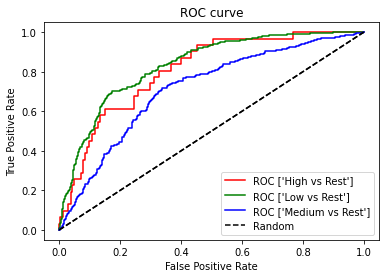

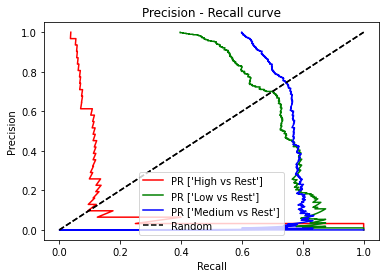

"\n{'pca__whiten': False, 'randomforestclassifier__ccp_alpha': 0.001, 'randomforestclassifier__class_weight': None, 'randomforestclassifier__max_depth': 12, 'randomforestclassifier__max_features': 8, 'randomforestclassifier__min_samples_split': 2, 'randomforestclassifier__n_estimators': 1000, 'smote__k_neighbors': 2}\n"

In [ ]:
pipeline = Pipeline(steps=[('columntranformation',column_tranformation),
                          ('scaler',scaler),
                          ('pca',pca),
                          ('randomforestclassifier',RandomForestClassifier(random_state=1))])

imb_pipeline = make_pipeline(column_tranformation,scaler,pca,over_samp,RandomForestClassifier(random_state=1))

param = {'pca__whiten':[False],
    'smote__k_neighbors':[2],'randomforestclassifier__n_estimators':[1000],
                        'randomforestclassifier__max_depth':[12],
                       'randomforestclassifier__min_samples_split':[2],
                       'randomforestclassifier__max_features':[8],
                        'randomforestclassifier__ccp_alpha':[0.001],
                        'randomforestclassifier__class_weight':[None]}

grid = GridSearchCV(estimator=imb_pipeline,
                cv=5,
                param_grid = param,
                verbose=2,
                return_train_score=True,
                n_jobs=-1,
               scoring='accuracy')

grid.fit(X_train,y_train)

set_config(display='diagram')
display(grid.best_estimator_)   

model_metrics_mul(grid,'randomforestclassifier')


'''
{'pca__whiten': False, 'randomforestclassifier__ccp_alpha': 0.001, 'randomforestclassifier__class_weight': None, 'randomforestclassifier__max_depth': 12, 'randomforestclassifier__max_features': 8, 'randomforestclassifier__min_samples_split': 2, 'randomforestclassifier__n_estimators': 1000, 'smote__k_neighbors': 2}
'''

# XGBooster

In [ ]:
'''{'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__max_depth': 6, 'xgbclassifier__n_estimators': 300, 'xgbclassifier__reg_lambda': 0, 'xgbclassifier__subsample': 0.9}'''

"{'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__max_depth': 6, 'xgbclassifier__n_estimators': 300, 'xgbclassifier__reg_lambda': 0, 'xgbclassifier__subsample': 0.9}"

XGBoost (and other gradient boosting machine routines too) has a number of parameters that can be tuned to avoid over-fitting. I will mention some of the most obvious ones. For example we can change:

- the ratio of features used (i.e. columns used); colsample_bytree. Lower ratios avoid over-fitting.
- the ratio of the training instances used (i.e. rows used); subsample. Lower ratios avoid over-fitting.
- the maximum depth of a tree; max_depth. Lower values avoid over-fitting.
- the minimum loss reduction required to make a further split; gamma. Larger values avoid over-fitting.
- the learning rate of our GBM (i.e. how much we update our prediction with each successive tree); eta. Lower values avoid over-fitting.
- the minimum sum of instance weight needed in a leaf, in certain applications this relates directly to the minimum number of instances needed in a node; min_child_weight. Larger values avoid over-fitting.

In [ ]:
high = sum(y_train==0.0)
low = sum(y_train==1.0)
medium = sum(y_train==2.0)
total = len(y_train)
weight_for_low = (1 / low) * (total / 3.0)
weight_for_medium = (1 / medium) * (total / 3.0)
weight_for_high = (1 / high) * (total / 3.0)

class_weight = {0: weight_for_high, 1: weight_for_low,2:weight_for_medium}
class_weight

{0: array([11.57377049]), 1: array([0.89423686]), 2: array([0.55700197])}

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train )

sample_weights

array([0.55700197, 0.55700197, 0.89423686, ..., 0.55700197, 0.55700197,
       0.55700197])

Fitting 5 folds for each of 1 candidates, totalling 5 fits


Pipeline(steps=[('columntranformation',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric_imputer',
                                                  KNNImputer(),
                                                  Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')),
                                                 ('categorical_transformation',
                                                  Pipeline...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cat_encoding',
                                                                   OneHotEncoder(drop='first'))]),
                                                  Index(['Type'], dtype='object'))])),
                ('scaler', MinMaxScaler()), ('pca', PCA(n_components=12)),
                ('xgbclassifier',
                 XGBClassifier(colsample_bytree=0.8, eval_metric='mlogloss',
                               learning_rate=0.01, max_depth=20,
                               n_estimators=8000, objective='multi:softprob',
                               random_state=1, reg_alpha=10, reg_lambda=50,
                               subsample=0.8))])



Best Accuracy:
--------------------------------------------------


,param_pca__whiten,param_xgbclassifier__colsample_bytree,param_xgbclassifier__learning_rate,param_xgbclassifier__max_depth,param_xgbclassifier__n_estimators,param_xgbclassifier__reg_alpha,param_xgbclassifier__reg_lambda,param_xgbclassifier__subsample,params,mean_train_score,mean_test_score
0,False,0.8,0.01,20,8000,10,50,0.8,"{'pca__whiten': False, 'xgbclassifier__colsamp...",0.920857,0.712703






Best Parameters:
--------------------------------------------------
{'pca__whiten': False, 'xgbclassifier__colsample_bytree': 0.8, 'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__max_depth': 20, 'xgbclassifier__n_estimators': 8000, 'xgbclassifier__reg_alpha': 10, 'xgbclassifier__reg_lambda': 50, 'xgbclassifier__subsample': 0.8}


Performance Metrics:
--------------------------------------------------
Accuracy 0.73

 Confusion Matrix :
--------------------------------------------------


array([[  3,   0,  28],
       [  0, 303,  91],
       [ 19, 149, 466]])

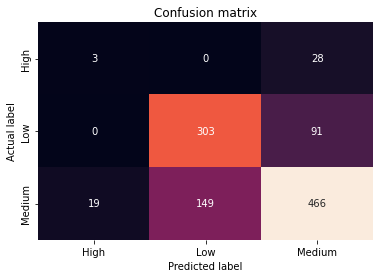


 Classification Report :
--------------------------------------------------
              precision    recall  f1-score   support

        High       0.14      0.10      0.11        31
         Low       0.67      0.77      0.72       394
      Medium       0.80      0.74      0.76       634

    accuracy                           0.73      1059
   macro avg       0.53      0.53      0.53      1059
weighted avg       0.73      0.73      0.73      1059



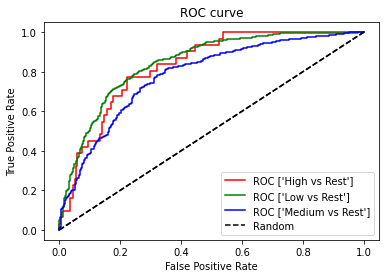

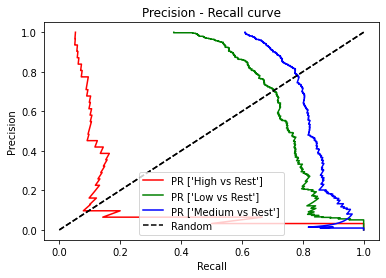

In [ ]:
pipeline = Pipeline(steps=[('columntranformation',column_tranformation),
                          ('scaler',scaler),
                          ('pca',pca),
                          ('xgbclassifier',XGBClassifier(random_state=1,eval_metric='mlogloss'))])

imb_pipeline = make_pipeline(column_tranformation,scaler,pca,over_samp,XGBClassifier(random_state=1,eval_metric='mlogloss'))

param ={'pca__whiten':[False]
    ,'xgbclassifier__learning_rate': [0.01], 
        'xgbclassifier__max_depth': [20], 
        'xgbclassifier__n_estimators': [8000], 
        'xgbclassifier__reg_alpha':[10],
        'xgbclassifier__reg_lambda': [50], 
        'xgbclassifier__subsample': [0.8],
       'xgbclassifier__colsample_bytree':[0.8]}



# {'xgbclassifier__n_estimators':range(100,700,100)}
#                         'xgbclassifier__max_depth':[4,5,6],
#                         'xgbclassifier__learning_rate':[0.1,0.05],
#                         'xgbclassifier__subsample':[1,0.9],
#                         'xgbclassifier__reg_lambda':[0,10,50]}

grid = GridSearchCV(estimator=pipeline,
                cv=5,
                param_grid = param,
                verbose=2,
                return_train_score=True,
                n_jobs=-1,
               scoring='accuracy')

grid.fit(X_train,y_train,xgbclassifier__sample_weight = sample_weights)

set_config(display='diagram')
display(grid.best_estimator_)   

model_metrics_mul(grid,'xgbclassifier')


In [ ]:
# pipeline = Pipeline(steps=[('columntranformation',column_tranformation),
#                           ('scaler',scaler),
#                           ('pca',pca),
#                           ('xgbclassifier',XGBClassifier(random_state=1,eval_metric='mlogloss'))])

# imb_pipeline = make_pipeline(column_tranformation,scaler,pca,over_samp,XGBClassifier(random_state=1,eval_metric='mlogloss'))

# param ={'pca__whiten':[True,False],'xgbclassifier__learning_rate': [0.05], 
#         'xgbclassifier__max_depth': [6], 
#         'xgbclassifier__n_estimators': [300], 
#         'xgbclassifier__reg_alpha':[10],
#         'xgbclassifier__reg_lambda': [50], 
#         'xgbclassifier__subsample': [0.8],
#        'xgbclassifier__colsample_bytree':[0.8]}



# param = {'xgbclassifier__n_estimators':range(100,700,100),
#                         'xgbclassifier__max_depth':[4,5,6],
#                         'xgbclassifier__learning_rate':[0.1,0.05],
#                         'xgbclassifier__subsample':[1,0.9],
#                         'xgbclassifier__reg_lambda':[0,10,50]}

# grid = GridSearchCV(estimator=pipeline,
#                 cv=5,
#                 param_grid = param,
#                 verbose=2,
#                 return_train_score=True,
#                 n_jobs=-1,
#                scoring='accuracy')

# grid.fit(X_train,y_train)

# set_config(display='diagram')
# display(grid.best_estimator_)   

# model_metrics_mul(grid,'xgbclassifier')

# {'xgbclassifier__learning_rate': 0.05, 'xgbclassifier__max_depth': 6, 'xgbclassifier__n_estimators': 300, 'xgbclassifier__reg_lambda': 50, 'xgbclassifier__subsample': 1}

In [ ]:
pd.DataFrame(grid.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_pca__whiten,param_xgbclassifier__colsample_bytree,param_xgbclassifier__learning_rate,param_xgbclassifier__max_depth,param_xgbclassifier__n_estimators,param_xgbclassifier__reg_alpha,param_xgbclassifier__reg_lambda,param_xgbclassifier__subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,230.432824,33.410455,6.206376,0.555819,False,0.8,0.01,20,8000,10,50,0.8,"{'pca__whiten': False, 'xgbclassifier__colsamp...",0.70283,0.713105,0.681228,0.742621,0.723731,0.712703,0.020518,1,0.922963,0.922986,0.918855,0.91738,0.922101,0.920857,0.002307


In [ ]:
pipeline = Pipeline(steps=[('columntranformation',column_tranformation),
                          ('scaler',scaler),
                          ('pca',pca),
                          ('xgbclassifier',XGBClassifier(random_state=1,eval_metric='mlogloss'))])

imb_pipeline = make_pipeline(column_tranformation,scaler,pca,over_samp,XGBClassifier(random_state=1,eval_metric='mlogloss'))

param ={'pca__whiten':[False],
    'smote__k_neighbors':[2],'xgbclassifier__learning_rate': [0.05], 
        'xgbclassifier__max_depth': [6], 
        'xgbclassifier__n_estimators': [8000], 
        'xgbclassifier__reg_alpha':[10],
        'xgbclassifier__reg_lambda': [50], 
        'xgbclassifier__subsample': [0.8],
       'xgbclassifier__colsample_bytree':[0.8]}



# {'xgbclassifier__n_estimators':range(100,700,100)}
#                         'xgbclassifier__max_depth':[4,5,6],
#                         'xgbclassifier__learning_rate':[0.1,0.05],
#                         'xgbclassifier__subsample':[1,0.9],
#                         'xgbclassifier__reg_lambda':[0,10,50]}

grid = GridSearchCV(estimator=imb_pipeline,
                cv=5,
                param_grid = param,
                verbose=2,
                return_train_score=True,
                n_jobs=-1,
               scoring='accuracy')

grid.fit(X_train,y_train)

set_config(display='diagram')
display(grid.best_estimator_)   

model_metrics_mul(grid,'xgbclassifier')


Fitting 5 folds for each of 1 candidates, totalling 5 fits


KeyboardInterrupt: ignored

In [ ]:
pd.DataFrame(grid.cv_results_)

# Model - Neural Network

In [ ]:
# pca = PCA(whiten=True)

In [ ]:
X_train_scaled = pd.DataFrame(pca.fit_transform(scaler.fit_transform(column_tranformation.fit_transform(X_train))),
                       index=X_train.index,columns=['PC'+str(i+1) for i in range(len(X_train.columns))])

X_test_scaled = pd.DataFrame(pca.transform(scaler.transform(column_tranformation.transform(X_test))),
                       index=X_test.index,columns=['PC'+str(i+1) for i in range(len(X_test.columns))])

## Oversampled

In [ ]:
X_train_oversampled,y_train_oversampled = over_samp.fit_resample(X_train_scaled,y_train)
X_train_oversampled

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
0,-0.160525,-0.335863,-0.350017,-0.200585,0.350651,-0.089111,0.013537,-0.048126,-0.130942,0.079013,-0.004932,0.018258
1,0.878714,-0.063727,0.278726,-0.017573,0.063181,0.013308,0.061134,-0.124376,0.139630,-0.114933,-0.017131,-0.053585
2,-0.407356,0.509325,-0.017707,-0.023390,0.078938,0.031249,-0.095178,0.089831,0.175480,-0.072089,-0.066809,-0.011409
3,0.896210,-0.123207,-0.490122,-0.076800,-0.135474,-0.113353,-0.143285,-0.014666,-0.099874,0.016104,0.036414,0.028585
4,-0.381672,-0.333659,0.398443,-0.036886,0.196231,0.116950,-0.143608,0.020614,0.088357,-0.086596,0.047149,0.116113
...,...,...,...,...,...,...,...,...,...,...,...,...
6644,0.926273,-0.047066,-0.543330,0.027684,-0.148182,-0.053766,-0.029491,0.051255,-0.023504,0.035674,0.023266,0.000591
6645,-0.294502,-0.179132,-0.137839,-0.175624,-0.233439,0.162049,-0.056456,0.023680,-0.038268,0.057335,-0.080886,-0.007587
6646,-0.332419,0.101730,0.044732,0.016804,-0.293922,0.012311,-0.128529,-0.014792,-0.190352,0.104918,-0.028495,0.024885
6647,-0.303427,-0.619798,0.288008,-0.090852,-0.017806,-0.066097,-0.099105,0.098832,-0.001073,-0.099129,-0.023881,0.035821


In [ ]:
X_train_oversampled

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
0,-0.160525,-0.335863,-0.350017,-0.200585,0.350651,-0.089111,0.013537,-0.048126,-0.130942,0.079013,-0.004932,0.018258
1,0.878714,-0.063727,0.278726,-0.017573,0.063181,0.013308,0.061134,-0.124376,0.139630,-0.114933,-0.017131,-0.053585
2,-0.407356,0.509325,-0.017707,-0.023390,0.078938,0.031249,-0.095178,0.089831,0.175480,-0.072089,-0.066809,-0.011409
3,0.896210,-0.123207,-0.490122,-0.076800,-0.135474,-0.113353,-0.143285,-0.014666,-0.099874,0.016104,0.036414,0.028585
4,-0.381672,-0.333659,0.398443,-0.036886,0.196231,0.116950,-0.143608,0.020614,0.088357,-0.086596,0.047149,0.116113
...,...,...,...,...,...,...,...,...,...,...,...,...
6644,0.926273,-0.047066,-0.543330,0.027684,-0.148182,-0.053766,-0.029491,0.051255,-0.023504,0.035674,0.023266,0.000591
6645,-0.294502,-0.179132,-0.137839,-0.175624,-0.233439,0.162049,-0.056456,0.023680,-0.038268,0.057335,-0.080886,-0.007587
6646,-0.332419,0.101730,0.044732,0.016804,-0.293922,0.012311,-0.128529,-0.014792,-0.190352,0.104918,-0.028495,0.024885
6647,-0.303427,-0.619798,0.288008,-0.090852,-0.017806,-0.066097,-0.099105,0.098832,-0.001073,-0.099129,-0.023881,0.035821


Epoch 1/1000
208/208 [==============================] - 1s 3ms/step - loss: 0.7964 - accuracy: 0.6054 - val_loss: 0.8755 - val_accuracy: 0.5241
Epoch 2/1000
208/208 [==============================] - 0s 2ms/step - loss: 0.7077 - accuracy: 0.6630 - val_loss: 0.7909 - val_accuracy: 0.5656
Epoch 3/1000
208/208 [==============================] - 1s 2ms/step - loss: 0.6559 - accuracy: 0.6994 - val_loss: 0.8240 - val_accuracy: 0.5751
Epoch 4/1000
208/208 [==============================] - 0s 2ms/step - loss: 0.6284 - accuracy: 0.7132 - val_loss: 0.7462 - val_accuracy: 0.6204
Epoch 5/1000
208/208 [==============================] - 0s 2ms/step - loss: 0.6071 - accuracy: 0.7248 - val_loss: 0.6915 - val_accuracy: 0.6771
Epoch 6/1000
208/208 [==============================] - 1s 2ms/step - loss: 0.5872 - accuracy: 0.7357 - val_loss: 0.7464 - val_accuracy: 0.6459
Epoch 7/1000
208/208 [==============================] - 0s 2ms/step - loss: 0.5740 - accuracy: 0.7382 - val_loss: 0.7314 - val_accuracy:

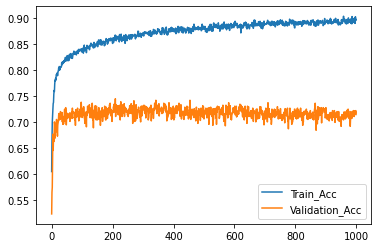

In [ ]:
np.random.seed(1)
set_seed(45)
tf_model = Sequential([Dense(128,activation=tf.nn.relu),
                       Dropout(0.2),
                       Dense(64,activation=tf.nn.relu),
                       Dropout(0.2),
                       Dense(32,activation=tf.nn.relu),
                       Dense(16,activation=tf.nn.relu),
                       Dense(3,activation='softmax')])

tf_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

history = tf_model.fit(X_train_oversampled,y_train_oversampled,batch_size=32,epochs=1000,validation_data = (X_test_scaled,y_test))

# history = tf_model.fit(X_train_oversampled,y_train_oversampled,batch_size=32,epochs=1000,validation_split=0.2)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(('Train_Acc','Validation_Acc'))
plt.show()

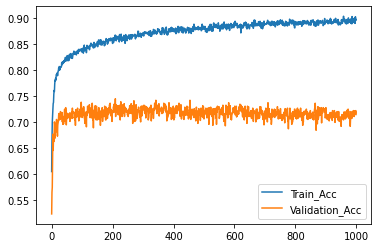

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(('Train_Acc','Validation_Acc'))
plt.show()

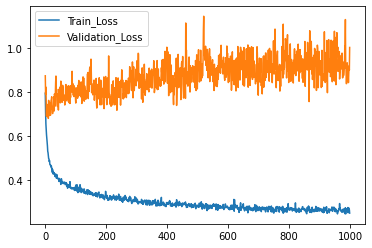

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(('Train_Loss','Validation_Loss'))
plt.show()

Performance Metrics:
--------------------------------------------------
Accuracy 0.71

 Confusion Matrix :
--------------------------------------------------


Predicted            
                   High  Low Medium
Actual High           6    1     24
       Low            1  244    149
       Medium        23  104    507

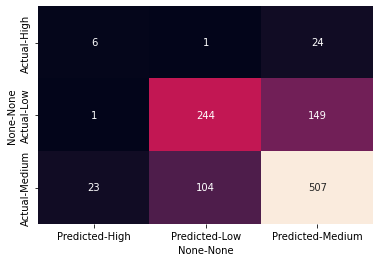


 Classification Report :
--------------------------------------------------
              precision    recall  f1-score   support

        High       0.20      0.19      0.20        31
         Low       0.70      0.62      0.66       394
      Medium       0.75      0.80      0.77       634

    accuracy                           0.71      1059
   macro avg       0.55      0.54      0.54      1059
weighted avg       0.71      0.71      0.71      1059



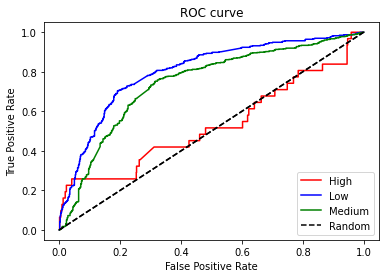

In [ ]:
predictions = tf_model.predict(X_test_scaled)
y_pred = np.argmax(predictions, axis=1) 
y_pred_prob = predictions

features = X_test.columns

print("Performance Metrics:")
print("-"*50)
print("Accuracy",round(accuracy_score(y_test,y_pred),2))
# print("Precision",round(precision_score(y_test,y_pred),2))
# print("Recall",round(recall_score(y_test,y_pred),2))

print("\n","Confusion Matrix :")
print("-"*50)
cm = confusion_matrix(y_test,y_pred)
total_classes = len(targets)
codes = [total_classes*[0], list(range(total_classes))]
cm = confusion_matrix(y_test, y_pred)
cm_frame = pd.DataFrame(data=cm, 
                        columns=pd.MultiIndex(levels=[['Predicted'], targets], codes=codes), 
                        index=pd.MultiIndex(levels=[['Actual'], targets], codes=codes)) 
display(cm_frame)
sns.heatmap(cm_frame,cbar=False,annot=True,fmt="d",xticklabels=True,yticklabels=True)
plt.show()

print("\n","Classification Report :")
print("-"*50)
print(classification_report(y_test,y_pred,target_names=targets))

fpr, tpr, thresh = roc_curve(y_test, y_pred_prob[:,0],pos_label=0)
fpr1, tpr1, thresh1 = roc_curve(y_test, y_pred_prob[:,1:2],pos_label=1)
fpr2, tpr2, thresh2 = roc_curve(y_test, y_pred_prob[:,-1],pos_label=2)

# plotting 
plt.plot(fpr, tpr,color='red')
plt.plot(fpr1, tpr1,color='blue')
plt.plot(fpr2, tpr2,color='green')
plt.plot([(0,0),(1,1)],linestyle = "--",color = "black")
plt.legend(("High",'Low','Medium',"Random"))
plt.title('ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel("True Positive Rate")
plt.show()

# pre,rec,thresh = precision_recall_curve(y_test, y_pred_prob[:,0],pos_label=1) 
# plt.plot(rec, pre,color='red')
# plt.plot([(0,0),(1,1)],linestyle = "--",color = "black")
# plt.legend((f"ROC ","Random"))
# plt.title('Precision - Recall curve')
# plt.xlabel('Recall')
# plt.ylabel("Precision")
# plt.show()

---

# Imbalanced Data

In [ ]:
X_train_scaled = pd.DataFrame(pca.fit_transform(scaler.fit_transform(column_tranformation.fit_transform(X_train))),
                       index=X_train.index,columns=X_train.columns)

X_test_scaled = pd.DataFrame(pca.transform(scaler.transform(column_tranformation.transform(X_test))),
                       index=X_test.index,columns=X_test.columns)

In [ ]:
set_seed(3)
tf_model = Sequential([Dense(128,activation=tf.nn.relu),
                       Dropout(0.2),
                       Dense(64,activation=tf.nn.relu),
                       Dropout(0.2),
                       Dense(32,activation=tf.nn.relu),
                       Dense(16,activation=tf.nn.relu),
                       Dense(3,activation='softmax')])

tf_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

high = sum(y_train==0.0)
low = sum(y_train==1.0)
medium = sum(y_train==2.0)
total = len(y_train)
weight_for_low = (1 / low) * (total / 3.0)
weight_for_medium = (1 / medium) * (total / 3.0)
weight_for_high = (1 / high) * (total / 3.0)

class_weight = {0: weight_for_high, 1: weight_for_low,2:weight_for_medium}
class_weight

{0: array([11.57377049]), 1: array([0.89423686]), 2: array([0.55700197])}

In [ ]:
history = tf_model.fit(X_train_scaled,y_train,batch_size=32,epochs=1000,validation_data=(X_test_scaled,y_test),class_weight=class_weight)

Epoch 1/1000
133/133 [==============================] - 1s 4ms/step - loss: 0.9650 - accuracy: 0.3867 - val_loss: 0.8595 - val_accuracy: 0.4353
Epoch 2/1000
133/133 [==============================] - 0s 3ms/step - loss: 0.8580 - accuracy: 0.4313 - val_loss: 0.8527 - val_accuracy: 0.4693
Epoch 3/1000
133/133 [==============================] - 0s 2ms/step - loss: 0.8297 - accuracy: 0.5102 - val_loss: 0.8128 - val_accuracy: 0.5449
Epoch 4/1000
133/133 [==============================] - 0s 3ms/step - loss: 0.8100 - accuracy: 0.5151 - val_loss: 0.8620 - val_accuracy: 0.5260
Epoch 5/1000
133/133 [==============================] - 0s 3ms/step - loss: 0.8108 - accuracy: 0.4908 - val_loss: 0.7879 - val_accuracy: 0.5760
Epoch 6/1000
133/133 [==============================] - 0s 3ms/step - loss: 0.7904 - accuracy: 0.5028 - val_loss: 0.8705 - val_accuracy: 0.5401
Epoch 7/1000
133/133 [==============================] - 0s 3ms/step - loss: 0.8072 - accuracy: 0.5453 - val_loss: 0.9766 - val_accuracy:

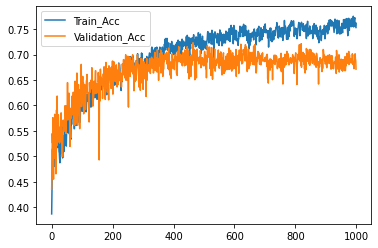

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(('Train_Acc','Validation_Acc'))
plt.show()

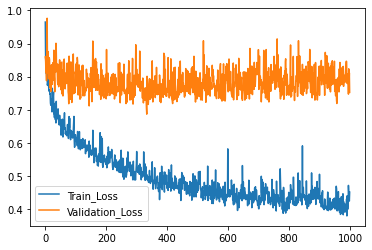

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(('Train_Loss','Validation_Loss'))
plt.show()

Performance Metrics:
--------------------------------------------------
Accuracy 0.67

 Confusion Matrix :
--------------------------------------------------


Predicted            
                   High  Low Medium
Actual High           5    0     26
       Low            3  189    202
       Medium        44   73    517

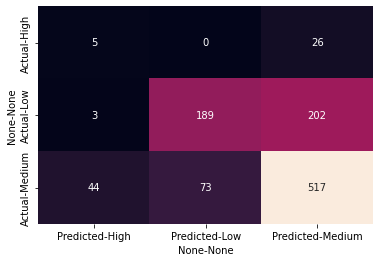


 Classification Report :
--------------------------------------------------
              precision    recall  f1-score   support

        High       0.10      0.16      0.12        31
         Low       0.72      0.48      0.58       394
      Medium       0.69      0.82      0.75       634

    accuracy                           0.67      1059
   macro avg       0.50      0.49      0.48      1059
weighted avg       0.69      0.67      0.67      1059



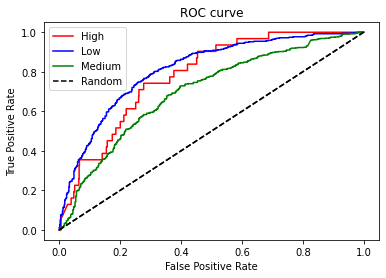

In [ ]:
predictions = tf_model.predict(X_test_scaled)
y_pred = np.argmax(predictions, axis=1) 
y_pred_prob = predictions

features = X_test.columns

print("Performance Metrics:")
print("-"*50)
print("Accuracy",round(accuracy_score(y_test,y_pred),2))
# print("Precision",round(precision_score(y_test,y_pred),2))
# print("Recall",round(recall_score(y_test,y_pred),2))

print("\n","Confusion Matrix :")
print("-"*50)
cm = confusion_matrix(y_test,y_pred)
total_classes = len(targets)
codes = [total_classes*[0], list(range(total_classes))]
cm = confusion_matrix(y_test, y_pred)
cm_frame = pd.DataFrame(data=cm, 
                        columns=pd.MultiIndex(levels=[['Predicted'], targets], codes=codes), 
                        index=pd.MultiIndex(levels=[['Actual'], targets], codes=codes)) 
display(cm_frame)
sns.heatmap(cm_frame,cbar=False,annot=True,fmt="d",xticklabels=True,yticklabels=True)
plt.show()

print("\n","Classification Report :")
print("-"*50)
print(classification_report(y_test,y_pred,target_names=targets))

fpr, tpr, thresh = roc_curve(y_test, y_pred_prob[:,0],pos_label=0)
fpr1, tpr1, thresh1 = roc_curve(y_test, y_pred_prob[:,1:2],pos_label=1)
fpr2, tpr2, thresh2 = roc_curve(y_test, y_pred_prob[:,-1],pos_label=2)

# plotting 
plt.plot(fpr, tpr,color='red')
plt.plot(fpr1, tpr1,color='blue')
plt.plot(fpr2, tpr2,color='green')
plt.plot([(0,0),(1,1)],linestyle = "--",color = "black")
plt.legend(("High",'Low','Medium',"Random"))
plt.title('ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel("True Positive Rate")
plt.show()

# pre,rec,thresh = precision_recall_curve(y_test, y_pred_prob[:,0],pos_label=1) 
# plt.plot(rec, pre,color='red')
# plt.plot([(0,0),(1,1)],linestyle = "--",color = "black")
# plt.legend((f"ROC ","Random"))
# plt.title('Precision - Recall curve')
# plt.xlabel('Recall')
# plt.ylabel("Precision")
# plt.show()

# AdaboostClassifier

Fitting 5 folds for each of 1 candidates, totalling 5 fits


Pipeline(steps=[('columntranformation',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric_imputer',
                                                  KNNImputer(),
                                                  Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')),
                                                 ('categorical_transformation',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cat_encoding',
                                                                   OneHotEncoder(drop='first'))]),
                                                  Index(['Type'], dtype='object'))])),
                ('scaler', MinMaxScaler()),
                ('pca', PCA(n_components=12, whiten=True)),
                ('adaboostclassifier',
                 AdaBoostClassifier(algorithm='SAMME', learning_rate=0.1,
                                    n_estimators=4000, random_state=1))])



Best Accuracy:
--------------------------------------------------


,param_adaboostclassifier__algorithm,param_adaboostclassifier__learning_rate,param_adaboostclassifier__n_estimators,param_pca__whiten,params,mean_train_score,mean_test_score
0,SAMME,0.1,4000,True,"{'adaboostclassifier__algorithm': 'SAMME', 'ad...",0.71217,0.699949






Best Parameters:
--------------------------------------------------
{'adaboostclassifier__algorithm': 'SAMME', 'adaboostclassifier__learning_rate': 0.1, 'adaboostclassifier__n_estimators': 4000, 'pca__whiten': True}


Performance Metrics:
--------------------------------------------------
Accuracy 0.72

 Confusion Matrix :
--------------------------------------------------


array([[  0,   1,  30],
       [  0, 241, 153],
       [  0, 114, 520]])

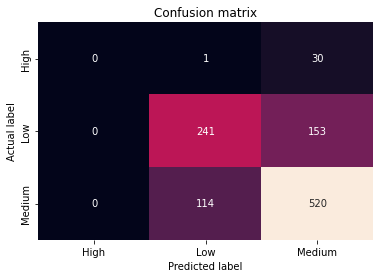


 Classification Report :
--------------------------------------------------
              precision    recall  f1-score   support

        High       0.00      0.00      0.00        31
         Low       0.68      0.61      0.64       394
      Medium       0.74      0.82      0.78       634

    accuracy                           0.72      1059
   macro avg       0.47      0.48      0.47      1059
weighted avg       0.69      0.72      0.70      1059



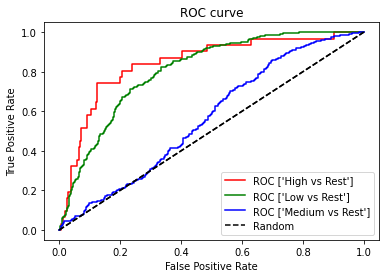

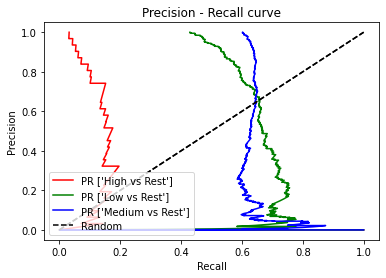

In [ ]:
pipeline = Pipeline(steps=[('columntranformation',column_tranformation),
                          ('scaler',scaler),
                          ('pca',pca),
                          ('adaboostclassifier',AdaBoostClassifier(random_state=1))])

imb_pipeline = make_pipeline(column_tranformation,scaler,pca,over_samp,AdaBoostClassifier(random_state=1))

param ={'pca__whiten':[True],'adaboostclassifier__n_estimators': [4000], 
        'adaboostclassifier__learning_rate': [0.1], 
        'adaboostclassifier__algorithm': ['SAMME']}


grid = GridSearchCV(estimator=pipeline,
                cv=5,
                param_grid = param,
                verbose=2,
                return_train_score=True,
                n_jobs=-1,
               scoring='accuracy')

# set_config(display='diagram')
# display(grid)

grid.fit(X_train,y_train)

set_config(display='diagram')
display(grid.best_estimator_)   

model_metrics_mul(grid,'adaboostclassifier')


Fitting 5 folds for each of 1 candidates, totalling 5 fits


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric_imputer',
                                                  KNNImputer(),
                                                  Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')),
                                                 ('categorical_transformation',
                                                  Pipeline(s...imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cat_encoding',
                                                                   OneHotEncoder(drop='first'))]),
                                                  Index(['Type'], dtype='object'))])),
                ('minmaxscaler', MinMaxScaler()), ('pca', PCA(n_components=12)),
                ('smote', SMOTE(random_state=1, sampling_strategy='minority')),
                ('adaboostclassifier',
                 AdaBoostClassifier(learning_rate=0.01, n_estimators=5000,
                                    random_state=1))])



Best Accuracy:
--------------------------------------------------


,param_adaboostclassifier__algorithm,param_adaboostclassifier__learning_rate,param_adaboostclassifier__n_estimators,param_pca__whiten,param_smote__k_neighbors,params,mean_train_score,mean_test_score
0,SAMME.R,0.01,5000,False,5,"{'adaboostclassifier__algorithm': 'SAMME.R', '...",0.593897,0.578144






Best Parameters:
--------------------------------------------------
{'adaboostclassifier__algorithm': 'SAMME.R', 'adaboostclassifier__learning_rate': 0.01, 'adaboostclassifier__n_estimators': 5000, 'pca__whiten': False, 'smote__k_neighbors': 5}


Performance Metrics:
--------------------------------------------------
Accuracy 0.61

 Confusion Matrix :
--------------------------------------------------


array([[ 17,   0,  14],
       [  6, 242, 146],
       [128, 114, 392]])

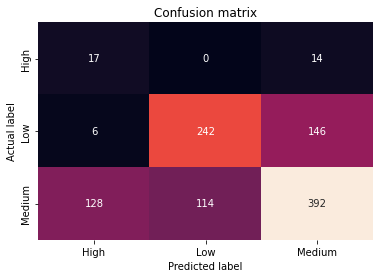


 Classification Report :
--------------------------------------------------
              precision    recall  f1-score   support

        High       0.11      0.55      0.19        31
         Low       0.68      0.61      0.65       394
      Medium       0.71      0.62      0.66       634

    accuracy                           0.61      1059
   macro avg       0.50      0.59      0.50      1059
weighted avg       0.68      0.61      0.64      1059



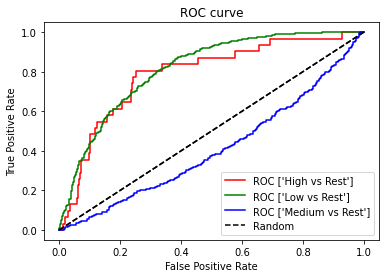

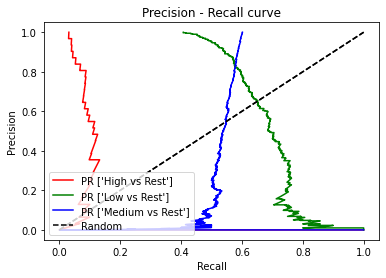

In [132]:
pipeline = Pipeline(steps=[('columntranformation',column_tranformation),
                          ('scaler',scaler),
                          ('pca',pca),
                          ('adaboostclassifier',AdaBoostClassifier(random_state=1))])

imb_pipeline = make_pipeline(column_tranformation,scaler,pca,over_samp,AdaBoostClassifier(random_state=1))

param ={'pca__whiten':[False],
    'smote__k_neighbors':[5],'adaboostclassifier__n_estimators': [5000], 
        'adaboostclassifier__learning_rate': [0.01], 
        'adaboostclassifier__algorithm': [ 'SAMME.R']}


grid = GridSearchCV(estimator=imb_pipeline,
                cv=5,
                param_grid = param,
                verbose=2,
                return_train_score=True,
                n_jobs=-1,
               scoring='accuracy')

# set_config(display='diagram')
# display(grid)

grid.fit(X_train,y_train)

set_config(display='diagram')
display(grid.best_estimator_)   

model_metrics_mul(grid,'adaboostclassifier')

# Gradient boost Classifier

Fitting 5 folds for each of 1 candidates, totalling 5 fits


Pipeline(steps=[('columntranformation',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric_imputer',
                                                  KNNImputer(),
                                                  Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')),
                                                 ('categorical_transformation',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cat_encoding',
                                                                   OneHotEncoder(drop='first'))]),
                                                  Index(['Type'], dtype='object'))])),
                ('scaler', MinMaxScaler()),
                ('pca', PCA(n_components=12, whiten=True)),
                ('gradientboostingclassifier',
                 GradientBoostingClassifier(learning_rate=0.05, max_depth=6,
                                            n_estimators=300, random_state=1,
                                            subsample=0.8))])



Best Accuracy:
--------------------------------------------------


,param_gradientboostingclassifier__learning_rate,param_gradientboostingclassifier__max_depth,param_gradientboostingclassifier__n_estimators,param_gradientboostingclassifier__subsample,param_pca__whiten,params,mean_train_score,mean_test_score
0,0.05,6,300,0.8,True,{'gradientboostingclassifier__learning_rate': ...,0.999528,0.725927






Best Parameters:
--------------------------------------------------
{'gradientboostingclassifier__learning_rate': 0.05, 'gradientboostingclassifier__max_depth': 6, 'gradientboostingclassifier__n_estimators': 300, 'gradientboostingclassifier__subsample': 0.8, 'pca__whiten': True}


Performance Metrics:
--------------------------------------------------
Accuracy 0.73

 Confusion Matrix :
--------------------------------------------------


array([[  0,   2,  29],
       [  0, 257, 137],
       [  2, 111, 521]])

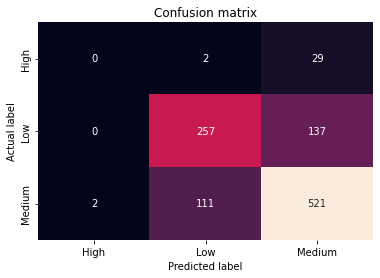


 Classification Report :
--------------------------------------------------
              precision    recall  f1-score   support

        High       0.00      0.00      0.00        31
         Low       0.69      0.65      0.67       394
      Medium       0.76      0.82      0.79       634

    accuracy                           0.73      1059
   macro avg       0.48      0.49      0.49      1059
weighted avg       0.71      0.73      0.72      1059



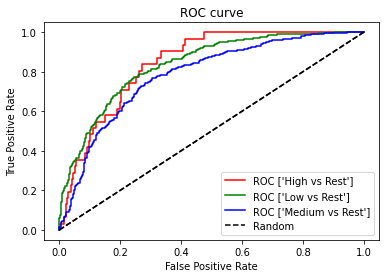

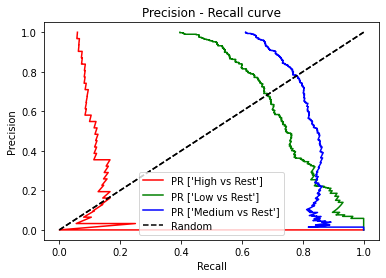

In [ ]:
pipeline = Pipeline(steps=[('columntranformation',column_tranformation),
                          ('scaler',scaler),
                          ('pca',pca),
                          ('gradientboostingclassifier',GradientBoostingClassifier(random_state=1))])

imb_pipeline = make_pipeline(column_tranformation,scaler,pca,over_samp,GradientBoostingClassifier(random_state=1))

param ={'pca__whiten':[True],'gradientboostingclassifier__n_estimators':[300],
                        'gradientboostingclassifier__max_depth':[6],
                        'gradientboostingclassifier__learning_rate':[0.05],
                        'gradientboostingclassifier__subsample':[0.8]}


# {'gradientboostingclassifier__learning_rate': [0.1], 
#         'gradientboostingclassifier__max_depth': [6], 
#         'gradientboostingclassifier__n_estimators': [300], 
#         'gradientboostingclassifier__subsample': [0.9]}

'''{'gradientboostingclassifier__learning_rate': 0.05, 
'gradientboostingclassifier__max_depth': 6, 
'gradientboostingclassifier__n_estimators': 300, 
'gradientboostingclassifier__subsample': 0.9}'''


grid = GridSearchCV(estimator=pipeline,
                cv=5,
                param_grid = param,
                verbose=2,
                return_train_score=True,
                n_jobs=-1,
               scoring='accuracy')

grid.fit(X_train,y_train)

set_config(display='diagram')
display(grid.best_estimator_)   

model_metrics_mul(grid,'gradientboostingclassifier')

Fitting 5 folds for each of 1 candidates, totalling 5 fits


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric_imputer',
                                                  KNNImputer(),
                                                  Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')),
                                                 ('categorical_transformation',
                                                  Pipeline(s...
                                                                  ('cat_encoding',
                                                                   OneHotEncoder(drop='first'))]),
                                                  Index(['Type'], dtype='object'))])),
                ('minmaxscaler', MinMaxScaler()), ('pca', PCA(n_components=12)),
                ('smote',
                 SMOTE(k_neighbors=2, random_state=1,
                       sampling_strategy='minority')),
                ('gradientboostingclassifier',
                 GradientBoostingClassifier(learning_rate=0.05, max_depth=6,
                                            n_estimators=500, random_state=1,
                                            subsample=0.8))])



Best Accuracy:
--------------------------------------------------


,param_gradientboostingclassifier__learning_rate,param_gradientboostingclassifier__max_depth,param_gradientboostingclassifier__n_estimators,param_gradientboostingclassifier__subsample,param_pca__whiten,param_smote__k_neighbors,params,mean_train_score,mean_test_score
0,0.05,6,500,0.8,False,2,{'gradientboostingclassifier__learning_rate': ...,1.0,0.707512






Best Parameters:
--------------------------------------------------
{'gradientboostingclassifier__learning_rate': 0.05, 'gradientboostingclassifier__max_depth': 6, 'gradientboostingclassifier__n_estimators': 500, 'gradientboostingclassifier__subsample': 0.8, 'pca__whiten': False, 'smote__k_neighbors': 2}


Performance Metrics:
--------------------------------------------------
Accuracy 0.73

 Confusion Matrix :
--------------------------------------------------


array([[  4,   0,  27],
       [  0, 267, 127],
       [ 27, 106, 501]])

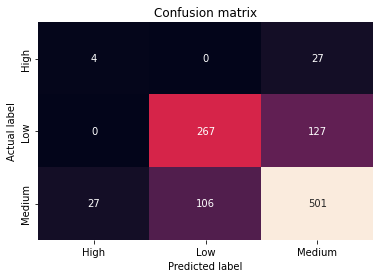


 Classification Report :
--------------------------------------------------
              precision    recall  f1-score   support

        High       0.13      0.13      0.13        31
         Low       0.72      0.68      0.70       394
      Medium       0.76      0.79      0.78       634

    accuracy                           0.73      1059
   macro avg       0.54      0.53      0.53      1059
weighted avg       0.73      0.73      0.73      1059



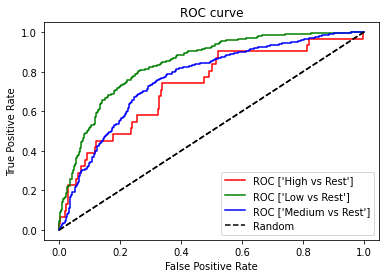

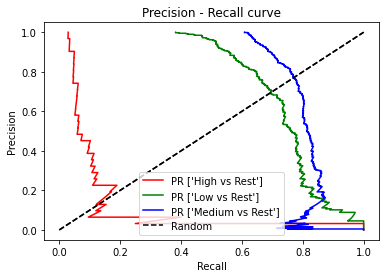

In [ ]:
pipeline = Pipeline(steps=[('columntranformation',column_tranformation),
                          ('scaler',scaler),
                          ('pca',pca),
                          ('gradientboostingclassifier',GradientBoostingClassifier(random_state=1))])

imb_pipeline = make_pipeline(column_tranformation,scaler,pca,over_samp,GradientBoostingClassifier(random_state=1))

param ={'pca__whiten':[False],
    'smote__k_neighbors':[2],'gradientboostingclassifier__n_estimators':[500],
                        'gradientboostingclassifier__max_depth':[6],
                        'gradientboostingclassifier__learning_rate':[0.05],
                        'gradientboostingclassifier__subsample':[0.8]}


# {'gradientboostingclassifier__learning_rate': [0.1], 
#         'gradientboostingclassifier__max_depth': [6], 
#         'gradientboostingclassifier__n_estimators': [300], 
#         'gradientboostingclassifier__subsample': [0.9]}

'''{'gradientboostingclassifier__learning_rate': 0.05, 
'gradientboostingclassifier__max_depth': 6, 
'gradientboostingclassifier__n_estimators': 300, 
'gradientboostingclassifier__subsample': 0.9}'''


grid = GridSearchCV(estimator=imb_pipeline,
                cv=5,
                param_grid = param,
                verbose=2,
                return_train_score=True,
                n_jobs=-1,
               scoring='accuracy')

grid.fit(X_train,y_train)

set_config(display='diagram')
display(grid.best_estimator_)   

model_metrics_mul(grid,'gradientboostingclassifier')

---